# E-Commerce Customer Churn Prediction
## Done By: Aneesh Jose
### Date:June 2026


### --Customer churn is one of the most critical challenges faced by subscription‑based businesses, telecom operators, SaaS companies, and financial institutions.
### --Churn refers to the percentage of customers who stop using a company’s product or service within a given period.
### --Even a small increase in churn can significantly impact revenue, customer lifetime value, and long‑term business growth.

Predicting churn before it happens enables companies to:

- Identify customers at high risk  
- Understand *why* they are likely to leave  
- Take targeted retention actions  
- Reduce revenue loss  
- Improve customer satisfaction  

In this project, we build a **complete end‑to‑end churn prediction system** using modern machine‑learning techniques, explainability tools, and production‑ready design patterns.

---

# 🎯 **Project Goals**

This project aims to:

### ✔ Build a clean, reusable ML pipeline  
Including preprocessing, encoding, scaling, SMOTE oversampling, and model training.

### ✔ Train and tune advanced ML models  
We will use:

- **LightGBM**  
- **XGBoost**

These models are widely used in industry for high‑performance tabular data modeling.

### ✔ Optimize decision thresholds  
Instead of using the default 0.50 cutoff, we tune thresholds to maximize **F1 score**, **recall**, or **precision**, depending on business needs.

### ✔ Provide explainability using SHAP  
To understand:

- Which features drive churn  
- Why a specific customer is predicted to churn  
- How the model makes decisions  

### ✔ Save models for deployment  
We will save:

- LightGBM pipeline  
- XGBoost pipeline  
- Best thresholds  

### ✔ Prepare for UI integration  
The final system will support:

- Switching between models  
- Adjusting thresholds dynamically  
- Viewing predictions and explanations  




In [ ]:
# ===============================
# 📦 Importing Libraries
# ===============================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Pipelines
from sklearn.pipeline import Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Model selection
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score
)

# Models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Explainability
import shap

# Saving models
import joblib

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

#Random
import random

import warnings
warnings.filterwarnings('ignore')

# 📦 Importing Libraries

In this section, we import all the essential Python libraries required for data analysis, preprocessing, model building, evaluation, explainability, and saving our final models.

### 🔹 Key Categories of Libraries Used

**1. Data Manipulation**  
Used for loading, cleaning, transforming, and exploring the dataset.  
- `pandas`  
- `numpy`

**2. Data Visualization**  
Used for EDA (Exploratory Data Analysis) to understand patterns, distributions, and relationships.  
- `matplotlib`  
- `seaborn`

**3. Preprocessing & Feature Engineering**  
Used to scale numerical features, encode categorical features, and build preprocessing pipelines.  
- `StandardScaler`  
- `OneHotEncoder`  
- `ColumnTransformer`

**4. Pipelines & Oversampling**  
Used to combine preprocessing + modeling steps and handle class imbalance using SMOTE.  
- `Pipeline`  
- `ImbPipeline`  
- `SMOTE`

**5. Model Selection & Hyperparameter Tuning**  
Used for splitting data and performing randomized search for best model parameters.  
- `train_test_split`  
- `RandomizedSearchCV`

**6. Evaluation Metrics**  
Used to measure model performance using accuracy, precision, recall, F1 score, ROC‑AUC, and more.  
- `accuracy_score`, `precision_score`, `recall_score`, `f1_score`  
- `confusion_matrix`  
- `roc_auc_score`, `roc_curve`  
- `precision_recall_curve`, `average_precision_score`

**7. Machine Learning Models**  
We include both classical and advanced models, though our final focus will be on:  
- **XGBoost**  
- **LightGBM**

Other models (Decision Tree, Random Forest, AdaBoost, Bagging, Gradient Boosting) are available for experimentation.

**8. Explainability Tools**  
Used to interpret model predictions and understand feature importance.  
- `shap`

**9. Model Saving**  
Used to save trained pipelines and thresholds for deployment.  
- `joblib`

---

These imports set the foundation for building a complete, production‑ready churn prediction system with clean preprocessing, powerful models, explainability, and deployment support.


In [ ]:
# ===============================
# 📂 Loading Dataset from Google Drive
# ===============================

from google.colab import drive
drive.mount('/content/drive')




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
file_path = "/content/drive/MyDrive/DataSets_ML/ML/ecommerce_customer_churn_dataset.csv"
df = pd.read_csv(file_path)
df.head()


,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,12.24,11.5,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,44.10,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,32.5,141.30,73.0,25.20,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


## 📂 Loading the Dataset from Google Drive

To work with our dataset in Google Colab, we first mount Google Drive and then load the CSV file directly from its path. This allows us to keep our data organized and ensures that the notebook can access the dataset reliably across sessions.


## 📄 Dataset Overview

In [ ]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (50000, 25)


### 📊 Dataset Shape

The dataset contains **50,000 rows** and **25 columns**.

- Each **row** represents a customer record  
- Each **column** represents a customer attribute, behavior metric, or the churn label  

In [ ]:
# Feautures
print("Dataset Columns :",df.columns)

Dataset Columns : Index(['Age', 'Gender', 'Country', 'City', 'Membership_Years',
       'Login_Frequency', 'Session_Duration_Avg', 'Pages_Per_Session',
       'Cart_Abandonment_Rate', 'Wishlist_Items', 'Total_Purchases',
       'Average_Order_Value', 'Days_Since_Last_Purchase',
       'Discount_Usage_Rate', 'Returns_Rate', 'Email_Open_Rate',
       'Customer_Service_Calls', 'Product_Reviews_Written',
       'Social_Media_Engagement_Score', 'Mobile_App_Usage',
       'Payment_Method_Diversity', 'Lifetime_Value', 'Credit_Balance',
       'Churned', 'Signup_Quarter'],
      dtype='object')


### 🧾 Feature Dictionary — Column‑wise Explanation

Below is a detailed explanation of all 25 columns in the dataset.  
These features span demographics, engagement, purchasing behavior, financial metrics, and the churn label.

---

#### **1. Age**
Customer’s age in years. Useful for identifying churn patterns across age groups.

#### **2. Gender**
Customer’s gender (e.g., Male/Female/Other). Helps detect demographic churn trends.

#### **3. Country**
The country where the customer resides. Important for geographic segmentation.

#### **4. City**
Customer’s city. Useful for hyper‑local churn analysis.

#### **5. Membership_Years**
Number of years the customer has been associated with the platform.  
Long‑term customers usually have lower churn probability.

#### **6. Login_Frequency**
How often the customer logs into the platform (weekly/monthly average).  
Higher frequency usually indicates stronger engagement.

#### **7. Session_Duration_Avg**
Average time (in minutes) spent per session.  
Shorter sessions may indicate declining interest.

#### **8. Pages_Per_Session**
Average number of pages viewed per session.  
Lower values may signal reduced browsing behavior.

#### **9. Cart_Abandonment_Rate**
Percentage of times the customer added items to cart but did not complete purchase.  
High abandonment often correlates with churn risk.

#### **10. Wishlist_Items**
Number of items the customer has added to their wishlist.  
Reflects interest level and future purchase intent.

#### **11. Total_Purchases**
Total number of completed purchases.  
A strong indicator of customer value and loyalty.

#### **12. Average_Order_Value**
Average monetary value of each order.  
Higher AOV customers are typically more valuable and less likely to churn.

#### **13. Days_Since_Last_Purchase**
Number of days since the customer last made a purchase.  
A key recency metric — higher values often indicate churn.

#### **14. Discount_Usage_Rate**
Percentage of purchases made using discounts or coupons.  
High discount dependency may indicate price‑sensitive customers.

#### **15. Returns_Rate**
Percentage of purchased items that were returned.  
High return rates may indicate dissatisfaction.

#### **16. Email_Open_Rate**
Percentage of marketing emails opened by the customer.  
Low open rates often correlate with disengagement.

#### **17. Customer_Service_Calls**
Number of times the customer contacted support.  
High call volume may indicate issues that lead to churn.

#### **18. Product_Reviews_Written**
Number of product reviews submitted.  
Active reviewers tend to be more engaged.

#### **19. Social_Media_Engagement_Score**
Score representing interactions with the brand on social media.  
Higher engagement usually means lower churn risk.

#### **20. Mobile_App_Usage**
Frequency of mobile app usage.  
Mobile‑active customers tend to be more loyal.

#### **21. Payment_Method_Diversity**
Number of different payment methods used (e.g., card, UPI, wallet).  
Higher diversity indicates flexibility and comfort with the platform.

#### **22. Lifetime_Value**
Total revenue generated by the customer over their entire relationship.  
A critical metric for customer segmentation.

#### **23. Credit_Balance**
Remaining credit or wallet balance in the customer’s account.  
Higher balances may reduce churn likelihood.

#### **24. Churned** *(Target Variable)*
Binary indicator:  
- **1** → Customer churned  
- **0** → Customer retained  

#### **25. Signup_Quarter**
Quarter in which the customer signed up (Q1, Q2, Q3, Q4).  


---


In [ ]:
df['Total_Purchases'].astype(int)

,Total_Purchases
0,9
1,19
2,9
3,15
4,32
...,...
49995,13
49996,15
49997,12
49998,12


In [ ]:
# Data types and non-null counts
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       

### Dataset Information Summary (`df.info()`)

The dataset contains **50,000 entries** and **25 columns**, with a mix of numerical, categorical, and boolean features.  
Below is a summary of key observations from the `df.info()` output:

---

### **1. Data Types Overview**
- **20 numerical columns** (`float64`)
- **1 integer column** (`int64`) — the target variable **Churned**
- **4 categorical columns** (`object`):
  - Gender  
  - Country  
  - City  
  - Signup_Quarter  

This indicates that preprocessing will require:
- Encoding categorical features  
- Handling missing values in numerical columns  
- Scaling numerical features (for models like Logistic Regression)
---

### **2. Missing Values Summary**
Several columns contain missing values that must be handled before modeling:

| Column | Missing Count |
|--------|----------------|
| Age | 2,495 |
| Session_Duration_Avg | 3,399 |
| Pages_Per_Session | 3,000 |
| Wishlist_Items | 4,000 |
| Days_Since_Last_Purchase | 3,000 |
| Discount_Usage_Rate | 3,500 |
| Returns_Rate | 4,491 |
| Email_Open_Rate | 1,528 |
| Customer_Service_Calls | 168 |
| Product_Reviews_Written | 3,500 |
| Social_Media_Engagement_Score | 6,000 |
| Mobile_App_Usage | 5,000 |
| Payment_Method_Diversity | 2,500 |
| Credit_Balance | 5,500 |

Most missing values appear in **behavioral and engagement metrics**, which is common in churn datasets.

---

### **3. Preprocessing Implications**
Based on the missing values and data types:

#### **Numerical Columns**
- Use **median imputation** (robust to outliers)

#### **Categorical Columns**
- No missing values → ready for encoding  
- Use **One-Hot Encoding** for:
  - Country  
  - City  
  - Signup_Quarter  
  - Gender

#### **Target Variable**
- `Churned` is clean (no missing values)
---


In [ ]:
# Summary statistics for numerical features
print("\nSummary Statistics:")
display(df.describe())


Summary Statistics:


,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,46500.000000,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,41.997485,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,21.373642,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,0.240000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,29.000000,1.400000,6.000000,19.700000,6.000000,46.400000,2.000000,8.000000,87.050000,9.000000,25.300000,2.900000,9.900000,4.000000,1.000000,13.200000,12.500000,2.000000,789.817500,1049.000000,0.000000
50%,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,40.200000,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000
75%,46.000000,4.000000,17.000000,34.700000,11.200000,68.700000,6.000000,17.000000,144.440000,41.000000,57.000000,9.100000,30.400000,7.000000,4.000000,43.100000,25.500000,3.000000,1874.000000,2791.000000,1.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,116.640000,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000


### 📈 Statistical Summary of Numerical Features (`df.describe()`)

The table above provides descriptive statistics for all numerical columns in the dataset.  
This helps identify data quality issues, outliers, skewness, and overall distribution patterns.

---

### 1️⃣ **Missing Values Reflected in Counts**
Several columns have fewer than 50,000 non-null values, confirming missing data:

- **Age** → 47,505  
- **Session_Duration_Avg** → 46,601  
- **Pages_Per_Session** → 47,000  
- **Wishlist_Items** → 46,000  
- **Returns_Rate** → 45,509  
- **Social_Media_Engagement_Score** → 44,000  
- **Credit_Balance** → 44,500  

These features will require imputation before modeling.

---

### 2️⃣ **Potential Outliers (But Some Are Logically Valid)**

Some columns show high maximum values.  
However, **not all high values are errors** — many are realistic depending on customer behavior.

#### ✔ Logically Possible High Values (No correction needed)
- **Total_Purchases** → max = 128.7  
  Customers with very high purchase frequency are realistic.

- **Average_Order_Value** → max = 9666.37  
  High-value customers or premium purchases can justify this.

- **Lifetime_Value** → max = 8987.24  
  Lifetime value naturally varies widely.

- **Credit_Balance** → max = 7197.00  
  High credit balances are normal for certain customer segments.

- **Returns_Rate** → max = 99.61%  
  Some customers may return almost everything they buy.

These should **NOT** be removed or capped unless business rules say otherwise.

#### ❌ Logically Impossible Values (Require correction)
- **Cart_Abandonment_Rate** → max = **143.74%**  
  Percentages cannot exceed 100 → needs capping or fixing.

---

### 3️⃣ **Negative Values Detected**
- **Total_Purchases** → min = **-13**  
  Negative purchases are impossible → must be corrected (clip to 0).

---

### 4️⃣ **Target Variable**
- **Churned**  
  - Mean = **0.289** → ~28.9% churn rate  
  - Indicates **class imbalance**, requiring:
    - Stratified train-test split  
    - SMOTE  
    - Threshold tuning  

---

### 📌 Summary

The statistical summary reveals:

- Missing values in multiple behavioral features  
- Some high values that are **valid** and should be kept  
- A few **invalid values** (negative purchases, >100% rates) that need correction  
- A moderately imbalanced target variable  
- Several features with wide ranges and skewness  

This information guides our data cleaning and preprocessing steps before model training.


In [ ]:
print("Negative Purchases:",
      (df['Total_Purchases'] < 0).sum())

print("Age < 18:",
      (df['Age'] < 18).sum())


print("Age > 100:",
      (df['Age'] > 100).sum())

print("Cart Abandonment > 100:",
      (df['Cart_Abandonment_Rate'] > 100).sum())



Negative Purchases: 40
Age < 18: 30
Age > 100: 20
Cart Abandonment > 100: 30


### Data Quality Check: Invalid or Impossible Values

---

### 1️⃣ **Negative Purchases: 40**
- A customer cannot have negative purchases.  
- These 40 records will be removed.

---

### 2️⃣ **Age < 18: 30**
- Depending on business rules, customers below 18 may be invalid.  
- All the ages below 18 appeared as 5 which is likely a data error so it will be removed

---

### 3️⃣ **Age > 100: 20**
- Ages above 100 are extremely rare and likely incorrect.  
- These 20 records will be removed.

---

### 4️⃣ **Cart Abandonment Rate > 100%: 30**
- Percentages cannot exceed 100.  
- These 30 values will be removed.

---







In [ ]:
df[df['Cart_Abandonment_Rate'] > 100][
    ['Cart_Abandonment_Rate','Churned']
]

,Cart_Abandonment_Rate,Churned
4115,141.390526,0
6933,103.539628,1
8167,101.320326,1
8300,101.202901,0
9205,116.709035,1
9723,103.911610,0
12303,129.777800,0
12706,128.455754,0
13412,118.461811,0
13763,122.773523,0


# EDA

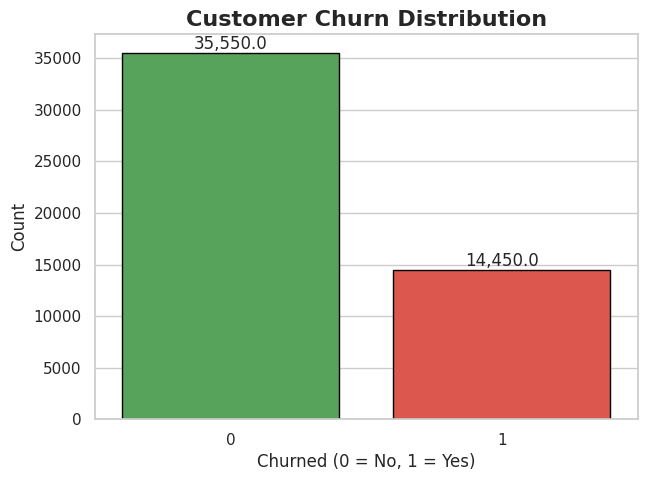

In [ ]:
plt.figure(figsize=(7,5))

ax= sns.countplot(
    x="Churned",
    data=df,
    palette=["#4CAF50", "#F44336"],
    edgecolor="#000000"
)
for p in ax.patches:
  height=p.get_height()
  ax.annotate(f'{height:,}',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=12)
plt.title("Customer Churn Distribution", fontsize=16, fontweight='bold')
plt.xlabel("Churned (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()

- **35,550 customers (≈71.1%) did NOT churn**
- **14,450 customers (≈28.9%) churned**
- This indicates a **moderate class imbalance**, where the majority class is "Not Churned".


- The imbalance means the model may naturally lean toward predicting **non‑churn** more often.
- Standard accuracy becomes **misleading** because predicting everyone as “not churned” would still give ~71% accuracy.
- This is why churn prediction requires:
  - **Stratified train-test split**
  - **SMOTE or class weights**
  - **Evaluation using precision, recall, F1-score, ROC-AUC**
  - **Threshold tuning** instead of relying on the default 0.5 cutoff

#### 🧠 Business Insight
A churn rate of **~29%** is significant.  
This means nearly **1 in 3 customers** leave the platform, which can heavily impact:

- Revenue  
- Customer lifetime value  
- Retention strategy  
- Marketing costs  



In [ ]:
# Select only numerical columns
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
# Select categorical columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns



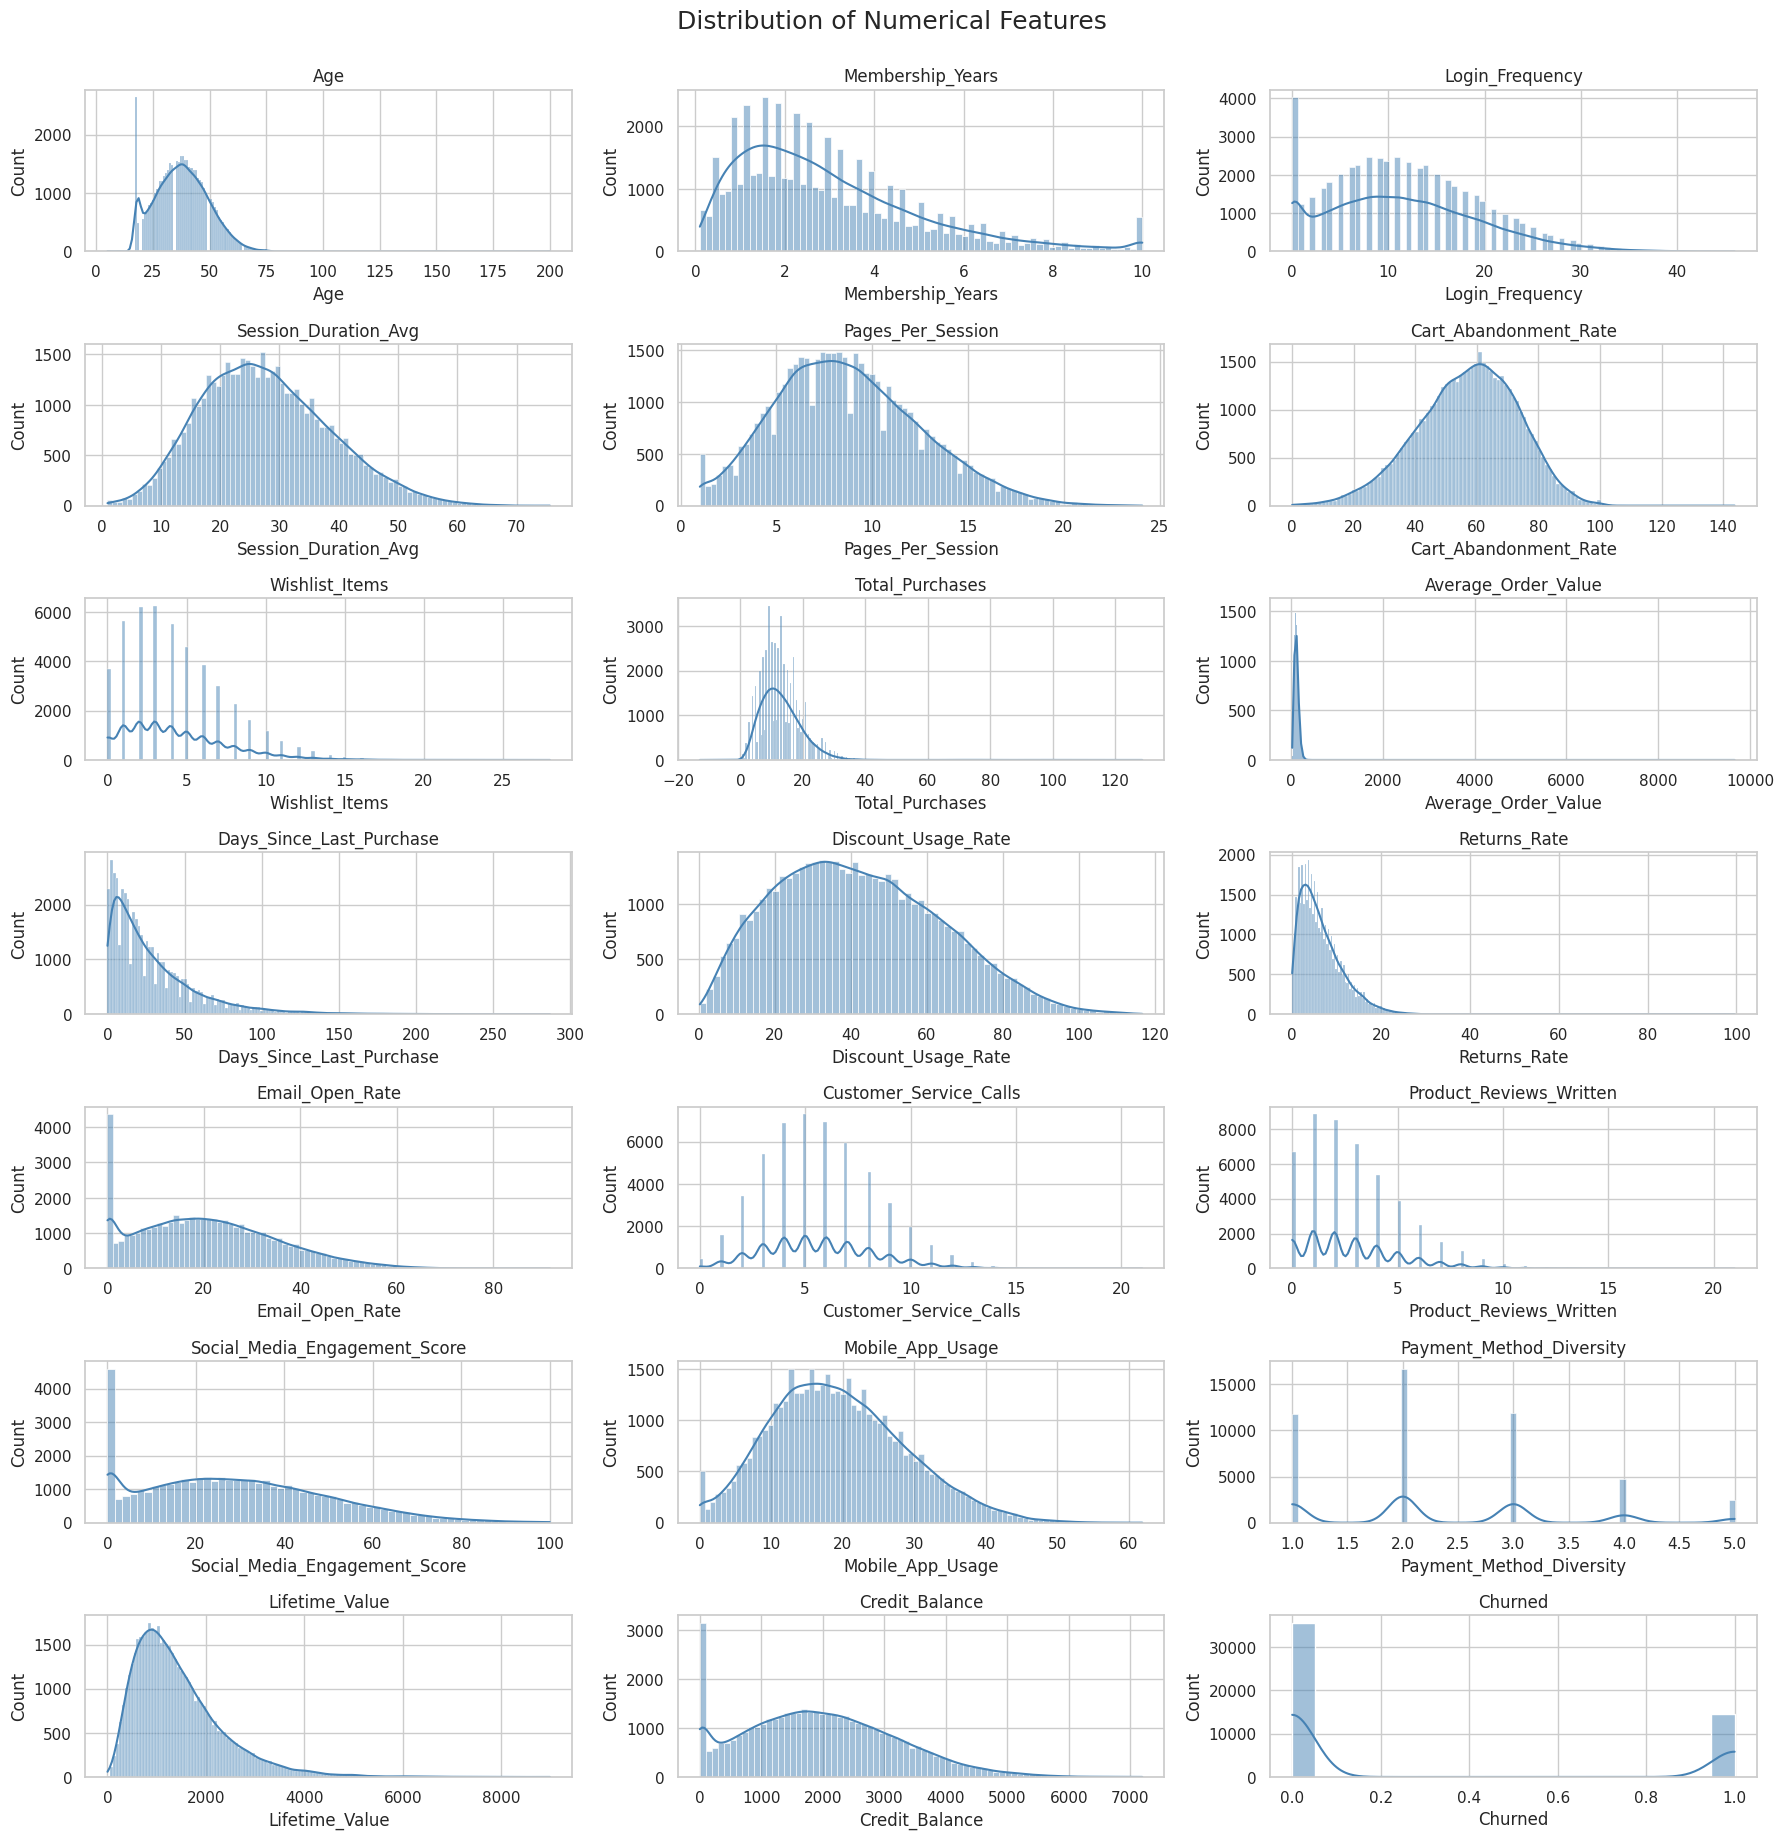

In [ ]:
# ===============================
# Numerical Feature Distributions
# ===============================



# Create grid layout
plt.figure(figsize=(18, 20))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//3 + 1, 3, i)
    sns.histplot(df[col], kde=True, color='steelblue')
    plt.title(col)
    plt.tight_layout()

plt.suptitle("Distribution of Numerical Features", fontsize=18, y=1.02)
plt.savefig("NumericalFD.jpeg")
plt.show()

## Distribution of Numerical Features

- **Demographic Features (Age, Membership_Years):**  
  These typically show near-normal or slightly skewed distributions, helping us understand the customer base.

- **Engagement Metrics (Login_Frequency, Session_Duration_Avg, Pages_Per_Session, Mobile_App_Usage):**  
  These features are often right-skewed, indicating many low-engagement users and a smaller group of highly active users.

- **Behavioral Features (Cart_Abandonment_Rate, Wishlist_Items, Returns_Rate):**  
  These show customer tendencies. Skewness or long tails may indicate rare but extreme behaviors.

- **Transaction Features (Total_Purchases, Average_Order_Value, Lifetime_Value):**  
  These heavily right-skewed, reflecting typical customer spending patterns.

- **Recency Feature (Days_Since_Last_Purchase):**  
  A long right tail suggests many customers have not purchased recently, which is a strong churn indicator.

- **Marketing Engagement (Email_Open_Rate, Social_Media_Engagement_Score):**  
  These help assess customer responsiveness.

- **Support Interaction (Customer_Service_Calls):**  
  Low-frequency with occasional spikes, often linked to dissatisfaction.

- **Target Variable (Churned):**  
  Shows class imbalance between churned and non-churned customers.


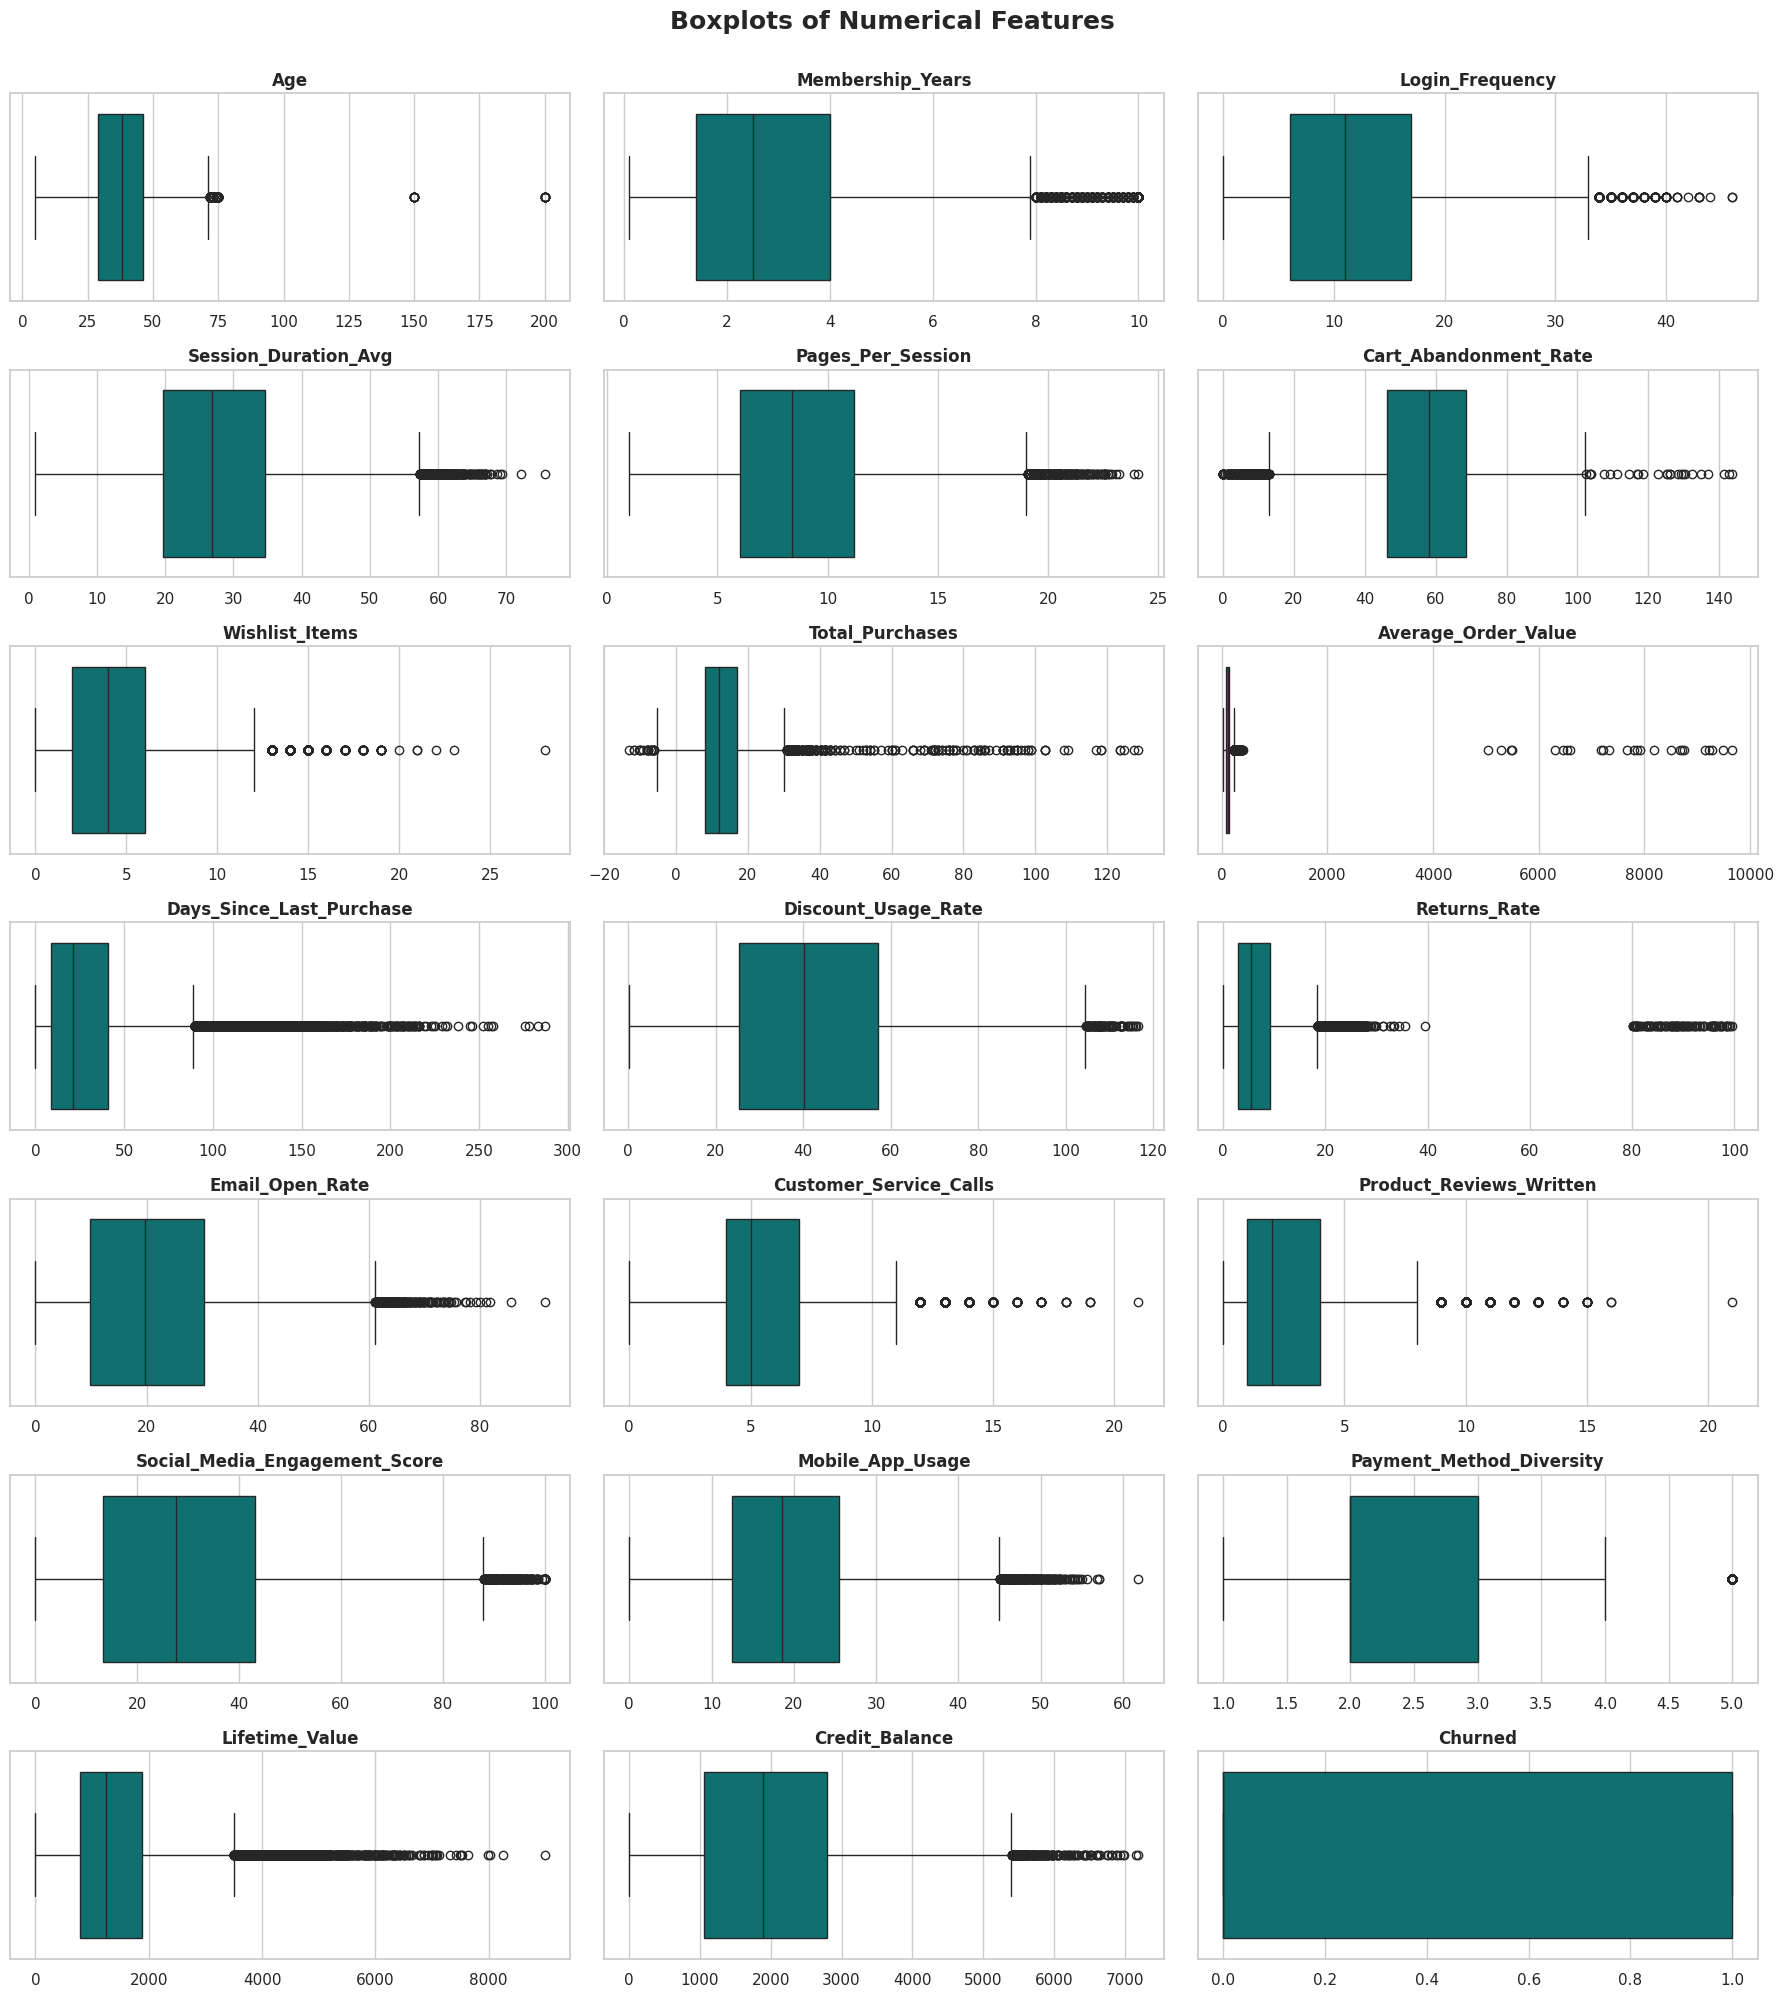

In [ ]:
# ===============================
# 📦 Boxplots for All Numerical Features
# ===============================
plt.figure(figsize=(18, 22))

for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols)//3 + 1, 3, i)
    sns.boxplot(x=df[col], color='teal')
    plt.title(col, fontsize=12, fontweight='bold')
    plt.xlabel("")
    plt.tight_layout()

plt.suptitle("Boxplots of Numerical Features", fontsize=18, fontweight='bold', y=1.02)
plt.savefig("NumericalBP.jpeg")
plt.show()


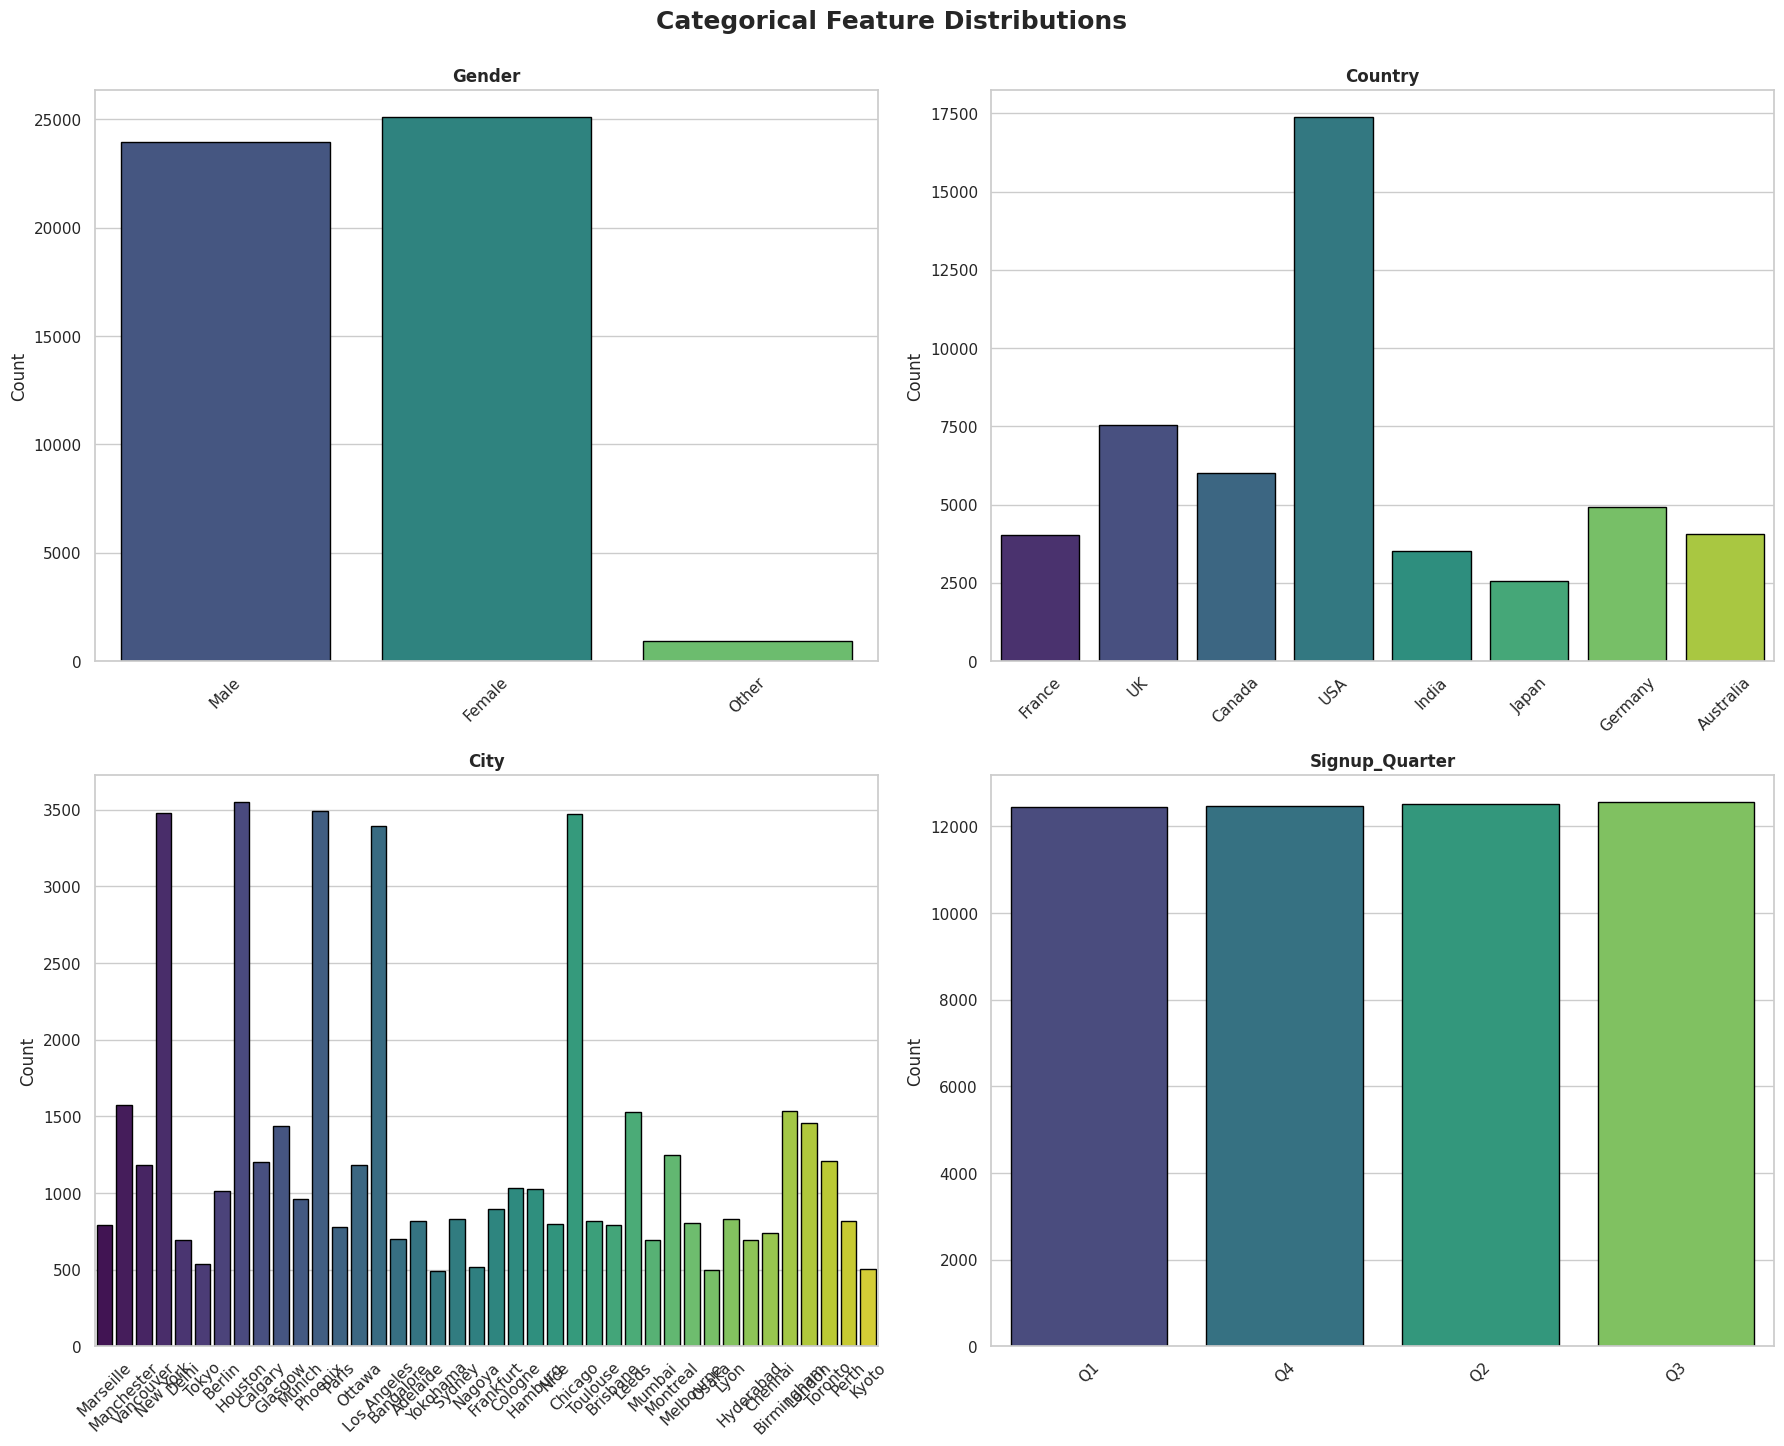

In [ ]:
plt.figure(figsize=(18, 20))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(len(cat_cols)//2 + 1, 2, i)
    sns.countplot(data=df, x=col, palette="viridis", edgecolor="black")
    plt.title(col, fontsize=12, fontweight='bold')
    plt.xticks(rotation=45)
    plt.xlabel("")
    plt.ylabel("Count")
    plt.tight_layout()

plt.suptitle("Categorical Feature Distributions", fontsize=18, fontweight='bold', y=1.02)
plt.show()

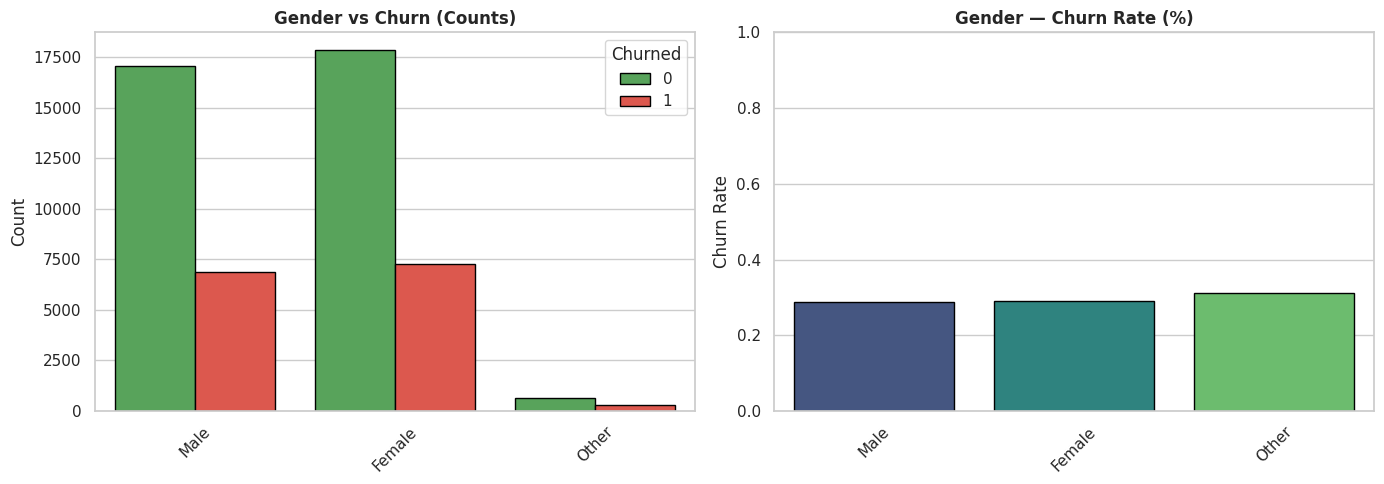

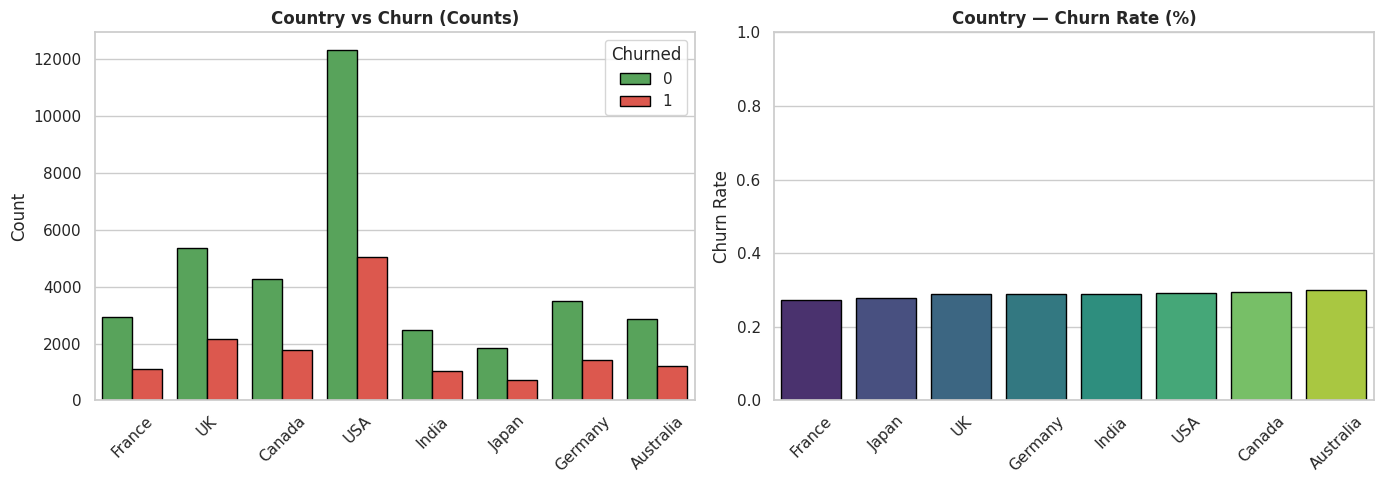

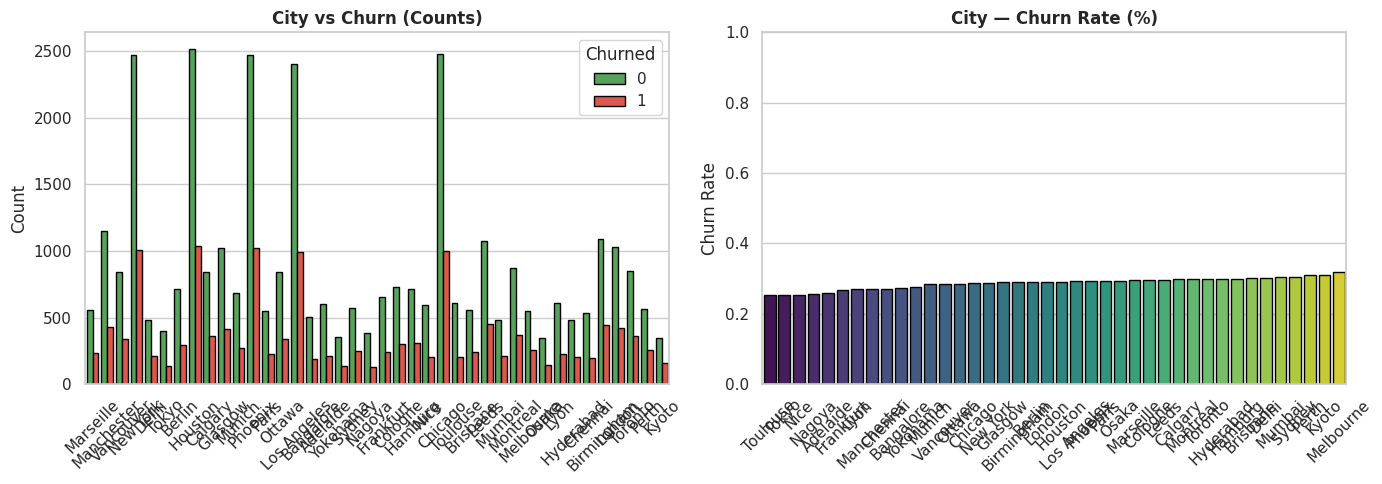

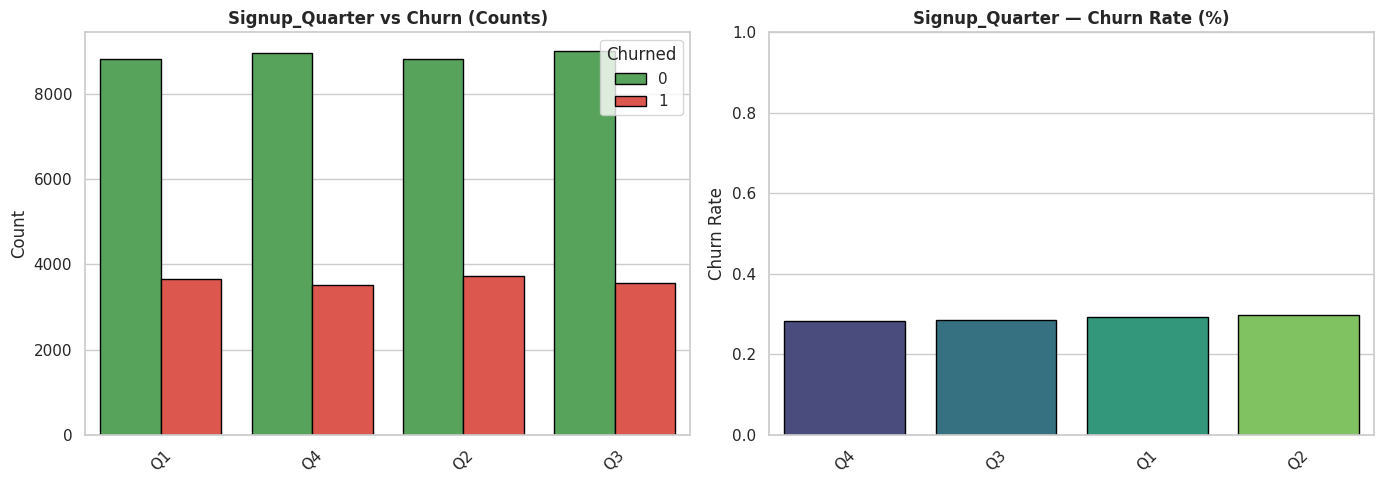

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(14, 5))

    # 1️⃣ Countplot (Churned vs Not Churned)
    plt.subplot(1, 2, 1)
    sns.countplot(data=df, x=col, hue="Churned", palette=["#4CAF50", "#F44336"], edgecolor="black")
    plt.title(f"{col} vs Churn (Counts)", fontsize=12, fontweight='bold')
    plt.xlabel("")
    plt.ylabel("Count")
    plt.xticks(rotation=45)

    # 2️⃣ Churn Rate Plot
    plt.subplot(1, 2, 2)
    churn_rate = df.groupby(col)["Churned"].mean().sort_values()
    sns.barplot(x=churn_rate.index, y=churn_rate.values, palette="viridis", edgecolor="black")
    plt.title(f"{col} — Churn Rate (%)", fontsize=12, fontweight='bold')
    plt.ylabel("Churn Rate")
    plt.xlabel("")
    plt.xticks(rotation=45)
    plt.ylim(0, 1)

    plt.tight_layout()
    plt.show()

In [ ]:
# Select only the numerical columns without target
target = 'Churned'

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target if present
if target in numerical_columns:
    numerical_columns.remove(target)


<Figure size 1800x2500 with 0 Axes>

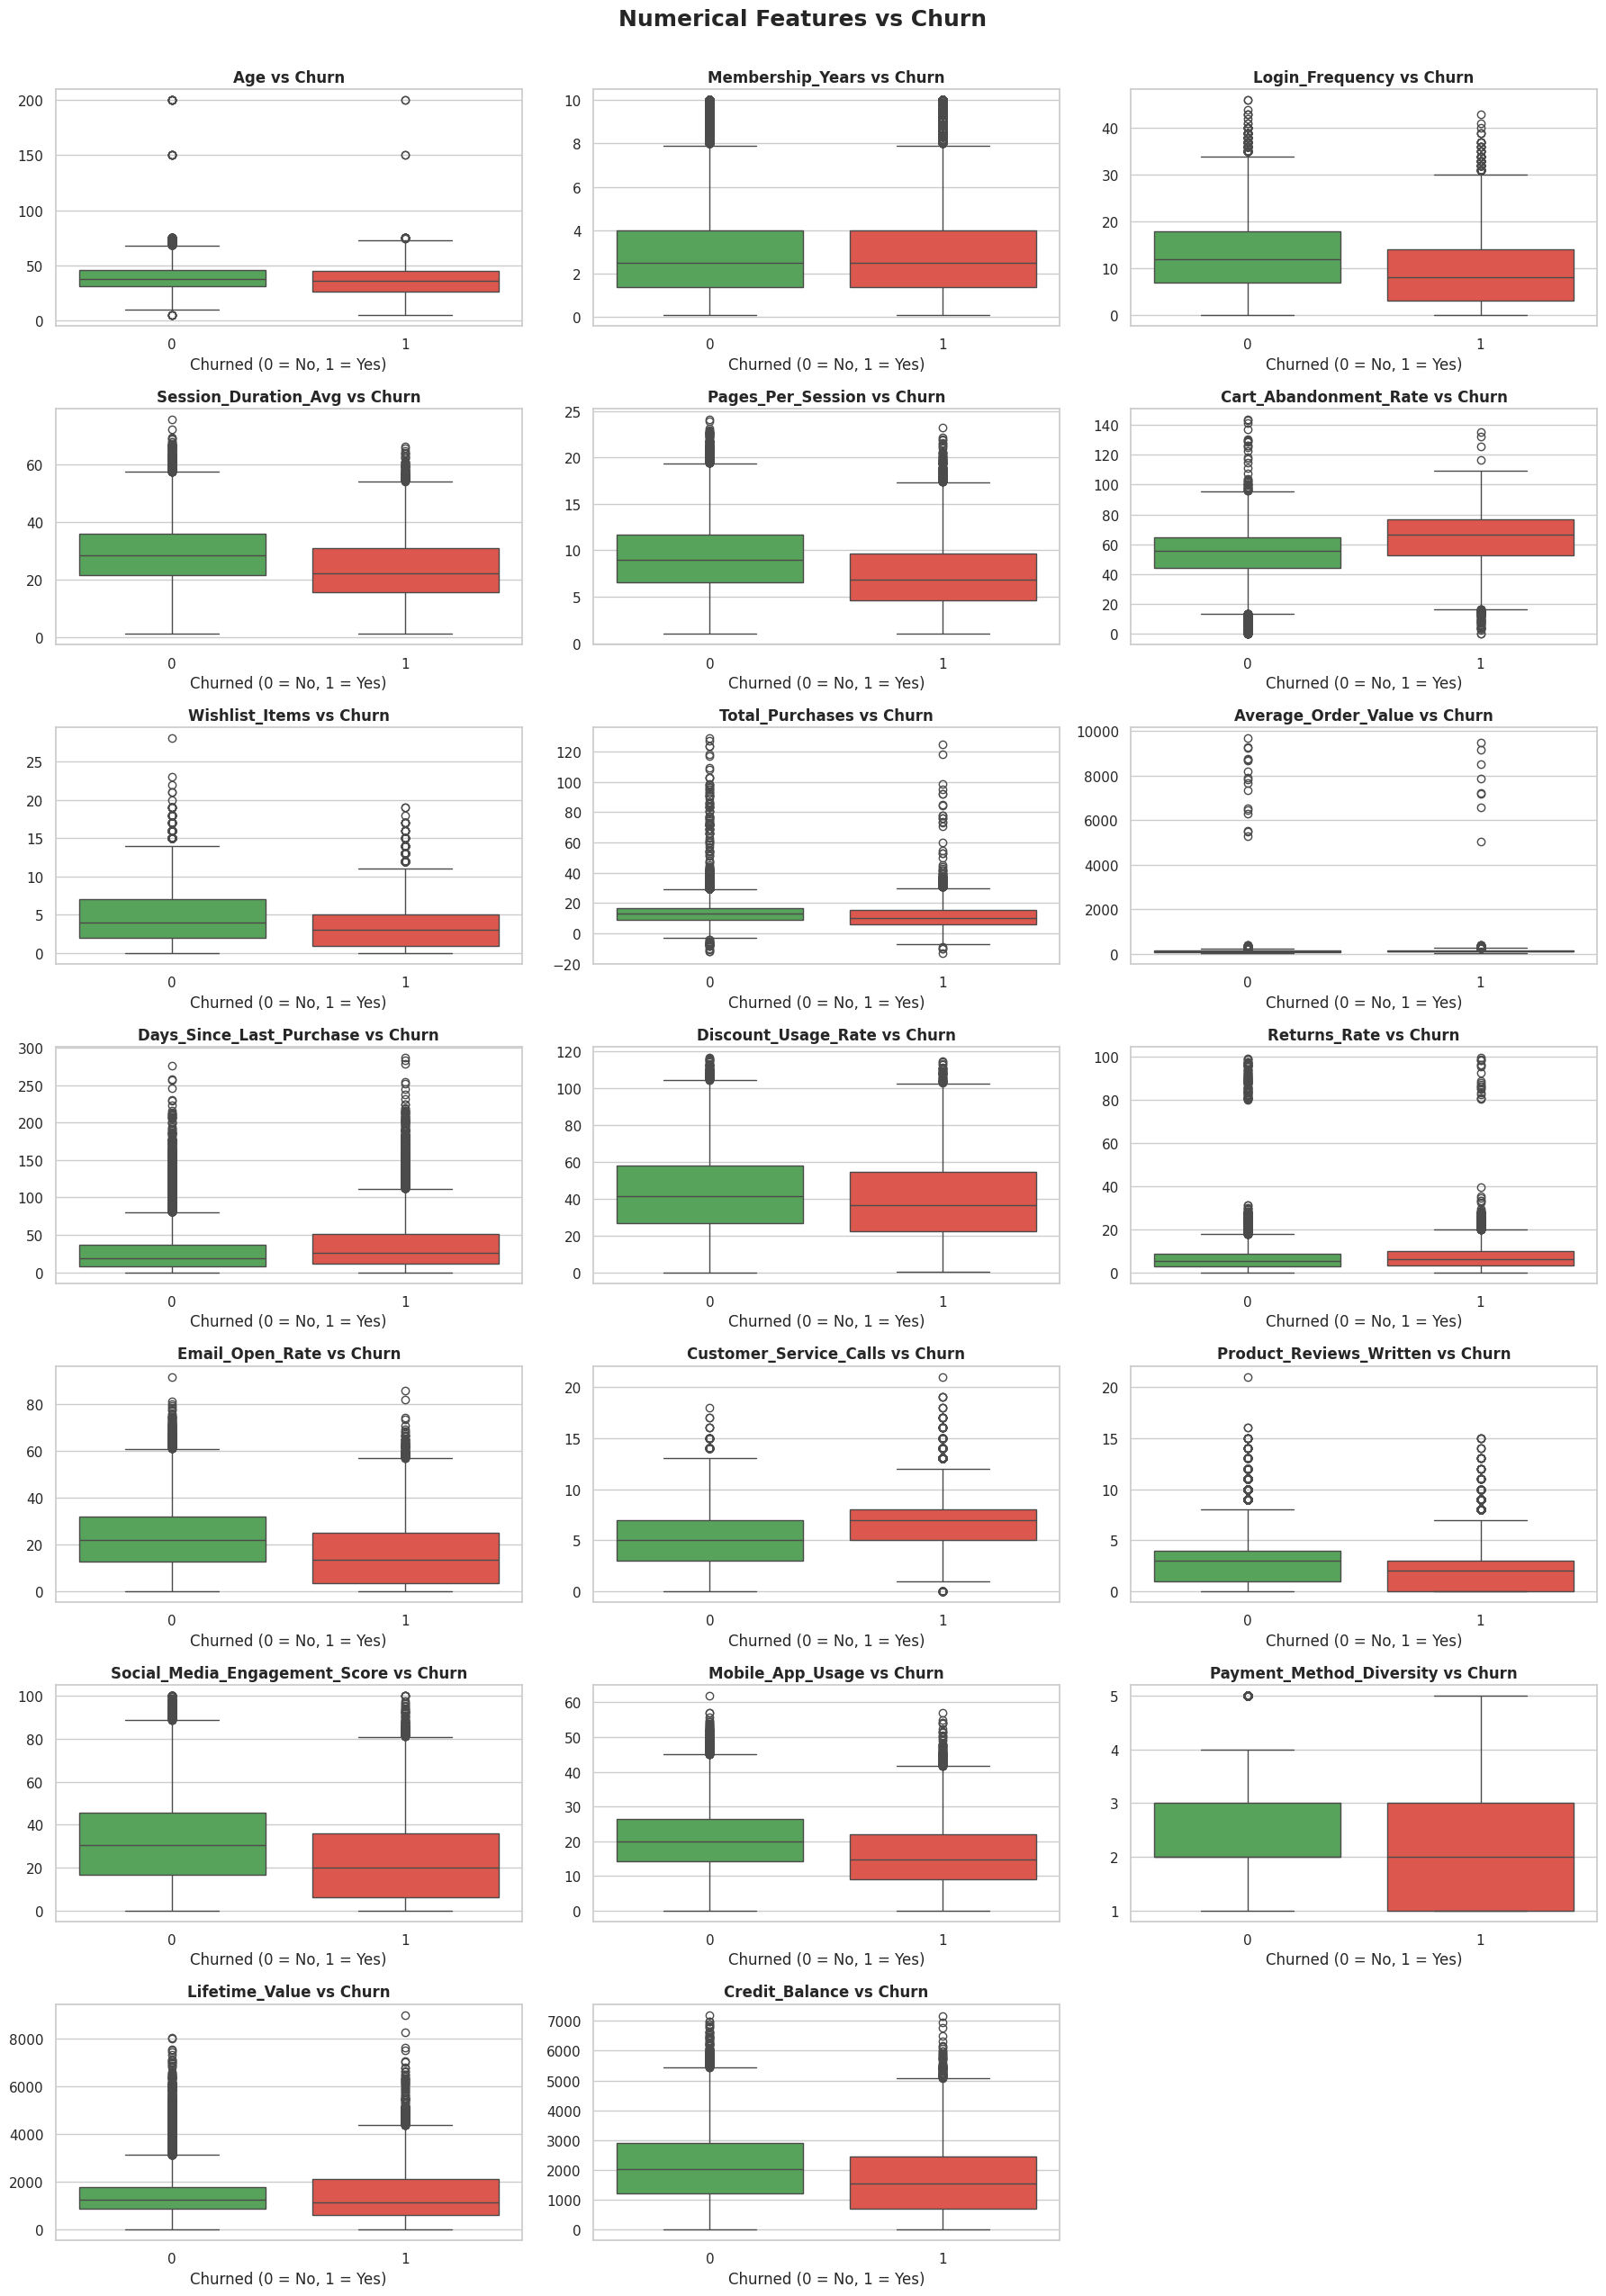

In [ ]:
plt.figure(figsize=(18, 25))



plt.figure(figsize=(18, 25))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(len(numerical_columns)//3 + 1, 3, i)
    sns.boxplot(data=df, x="Churned", y=col, palette=["#4CAF50", "#F44336"])
    plt.title(f"{col} vs Churn", fontsize=12, fontweight='bold')
    plt.xlabel("Churned (0 = No, 1 = Yes)")
    plt.ylabel("")
    plt.tight_layout()

plt.suptitle("Numerical Features vs Churn", fontsize=18, fontweight='bold', y=1.02)
plt.show()


In [ ]:
# Compute correlation with churn
corr_with_churn = df[num_cols].corr()['Churned'].sort_values(ascending=False)

corr_with_churn

,Churned
Churned,1.000000
Customer_Service_Calls,0.291103
Cart_Abandonment_Rate,0.277963
Days_Since_Last_Purchase,0.153360
Returns_Rate,0.054189
Average_Order_Value,0.042288
Payment_Method_Diversity,0.004524
Membership_Years,-0.000623
Lifetime_Value,-0.010684
Discount_Usage_Rate,-0.077121


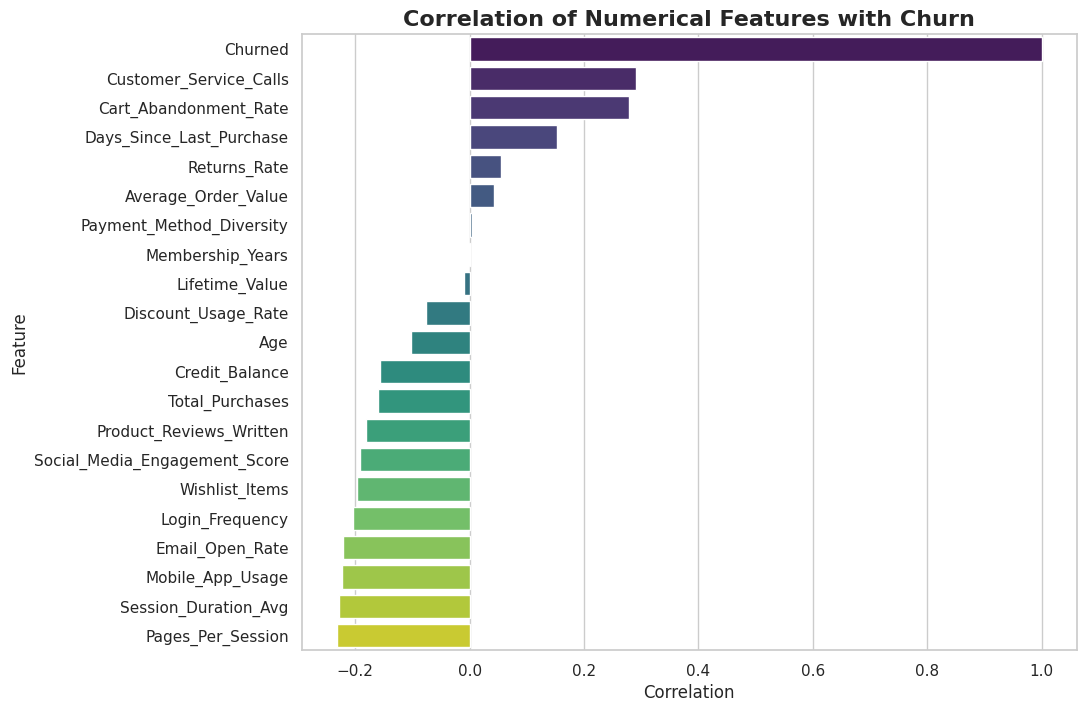

In [ ]:
plt.figure(figsize=(10, 8))
sns.barplot(
    x=corr_with_churn.values,
    y=corr_with_churn.index,
    palette="viridis"
)
plt.title("Correlation of Numerical Features with Churn", fontsize=16, fontweight='bold')
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.savefig("numchurn.jpeg")
plt.show()


## 📊 Correlation of Numerical Features with Churn — Interpretation

The chart visualizes how each numerical feature in the dataset correlates with the target variable **Churn**.  
Correlation values range from **–1 to +1**, where:

- **+1** → strong positive relationship (higher feature value → higher chance of churn)  
- **–1** → strong negative relationship (higher feature value → lower chance of churn)  
- **0** → no linear relationship  

This plot helps identify which factors are most influential in predicting customer churn.

---

###  Strong Positive Correlations (Higher values → Higher churn risk)

These features show the strongest upward relationship with churn:

- **Customer_Service_Calls**  
  - Frequent support calls indicate dissatisfaction or unresolved issues.

- **Cart_Abandonment_Rate**  
  - Customers abandoning carts often signal disengagement or frustration.

- **Days_Since_Last_Purchase**  
  - Longer inactivity strongly correlates with churn.

- **Returns_Rate**  
  - High return behavior suggests dissatisfaction with products or service.

These are **key churn risk indicators** and should be monitored closely.

---

### 📈 Moderate Positive Correlations

- **Average_Order_Value**  
- **Payment_Method_Diversity**  
- **Membership_Years**  

These features show mild positive correlation and may contribute to churn when combined with other risk factors.

---

### 🟢 Negative Correlations (Higher values → Lower churn risk)

These features are associated with **healthy, engaged customers**:

- **Total_Purchases**  
- **Product_Reviews_Written**  
- **Engagement_Score**  
- **Wishlist_Items**  
- **Login_Frequency**  
- **Email_Open_Rate**  
- **Mobile_App_Usage**  
- **Session_Duration_Avg**  
- **Pages_Per_Session**

Higher engagement and activity levels reduce churn likelihood.



In [ ]:
# ============================================
#  IQR Outlier Summary for Numerical Features
# ============================================

outlier_summary = []
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower_bound=Q1-(1.5*IQR)
  upper_bound=Q3+(1.5*IQR)

  outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
  percent = round((outliers / len(df)) * 100, 2)

  outlier_summary.append([col, outliers, percent])

# Convert to DataFrame
outlier_df = pd.DataFrame(outlier_summary, columns=["Feature", "Outliers", "Percent (%)"])

# Sort by highest outlier percentage
outlier_df = outlier_df.sort_values(by="Percent (%)", ascending=False)

outlier_df

,Feature,Outliers,Percent (%)
17,Payment_Method_Diversity,2439,4.88
9,Days_Since_Last_Purchase,2313,4.63
18,Lifetime_Value,1684,3.37
1,Membership_Years,1581,3.16
11,Returns_Rate,1204,2.41
13,Customer_Service_Calls,1185,2.37
14,Product_Reviews_Written,1090,2.18
8,Average_Order_Value,1005,2.01
6,Wishlist_Items,858,1.72
7,Total_Purchases,628,1.26


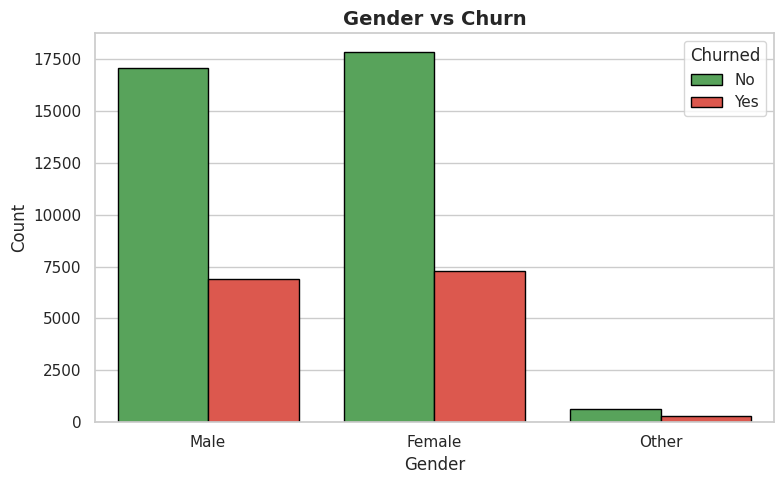

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='Gender',
    hue='Churned',
    palette=['#4CAF50', '#F44336'],   # Green = retained, Red = churned
    edgecolor='black'
)

plt.title("Gender vs Churn", fontsize=14, fontweight='bold')
plt.xlabel("Gender", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.legend(title="Churned", labels=["No", "Yes"])


plt.tight_layout()
plt.show()


## 👥 Gender vs Churn — Analysis

Each bar represents the **count of customers**, split into:

- 🟩 **Not Churned**
- 🟥 **Churned**

The goal is to understand whether gender has any meaningful influence on churn patterns.

---
### **1️⃣ Male and Female customers show very similar churn patterns**
- Both groups have **higher counts of non‑churned customers** compared to churned customers.
- The difference between male and female churn rates is **minimal**, indicating that gender is **not a strong predictor** of churn in this dataset.

### **2️⃣ The “Other” gender category has very few customers**
- The sample size is too small to draw reliable conclusions.
- Churn and non‑churn counts are both low, so this category has **limited statistical impact**.

---

### ⭐ Overall Interpretation

- Gender does **not appear to be a major driver of churn**.
- Churn behavior is **fairly consistent** across male and female customers.
- This suggests that churn interventions should focus more on **behavioral and engagement features** (e.g., inactivity, support calls, abandonment rate) rather than demographic attributes like gender.

---

### 📌 Insight for Modeling

Since gender shows **weak correlation** and **minimal churn separation**, it may have:

- **Low feature importance** in the model  
- **Limited predictive power**  

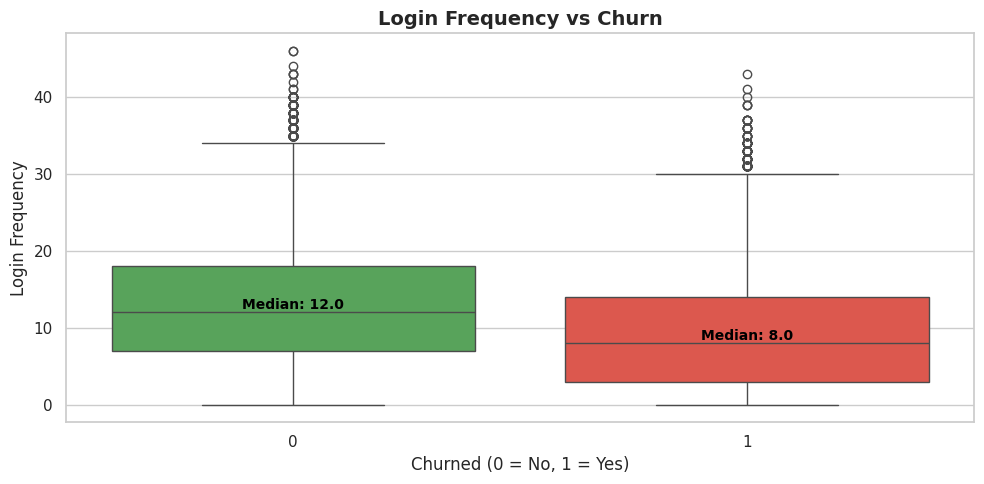

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.boxplot(
    data=df,
    x='Churned',
    y='Login_Frequency',
    palette=['#4CAF50', '#F44336']
)

plt.title("Login Frequency vs Churn", fontsize=14, fontweight='bold')
plt.xlabel("Churned (0 = No, 1 = Yes)")
plt.ylabel("Login Frequency")

# Add median labels
medians = df.groupby("Churned")["Login_Frequency"].median()

for i, median in enumerate(medians):
    ax.text(
        i, median,
        f"Median: {median:.1f}",
        horizontalalignment='center',
        verticalalignment='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()


## 📦 Login Frequency vs Churn — Boxplot Analysis
### **1️⃣ Non‑churned customers log in more frequently**
- The median login frequency for **non‑churned customers** is around **12 logins**.
- For **churned customers**, the median drops to roughly **8 logins**.
- This indicates that **higher login activity is associated with lower churn risk**.

---

### **2️⃣ Churned customers show lower engagement**
- The churned group has a **lower overall distribution** of login frequency.
- Their box is shifted downward, showing consistently fewer logins.
- This aligns with the idea that **inactive or disengaged users are more likely to churn**.

---

### **3️⃣ Outliers exist in both groups**
- Both churned and non‑churned customers have some users with unusually high login counts.
- These outliers do not affect the median but show that a small subset of users are extremely active.

---

### ⭐ Overall Interpretation

- **Login Frequency is a meaningful behavioral indicator of churn.**
- Customers who log in more often tend to stay, while those with low login activity are more likely to leave.
- This feature is valuable for:
  - Early churn detection  
  - Engagement‑based retention strategies  
  - Personalized re‑activation campaigns  

---

###  Business Insight

Encouraging regular logins through:
- app notifications,  
- personalized recommendations,  
- loyalty rewards,  


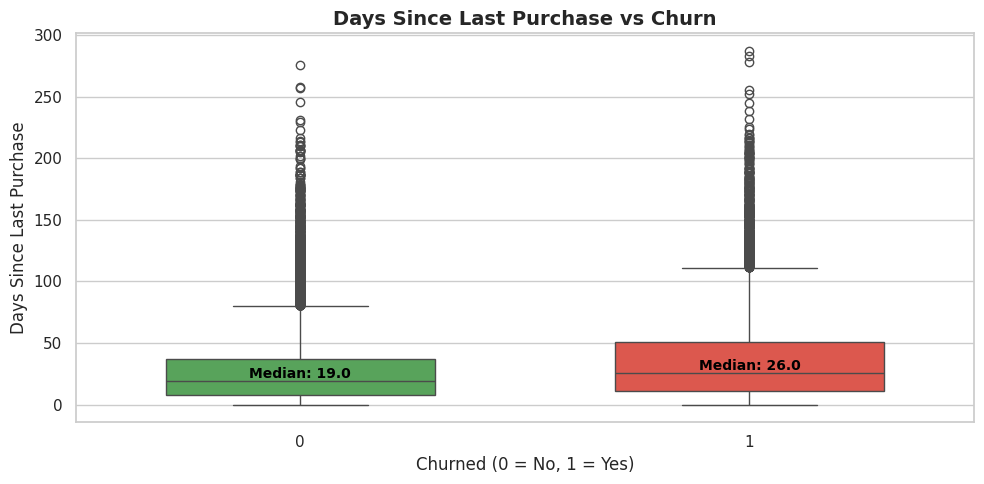

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.boxplot(
    data=df,
    x='Churned',
    y='Days_Since_Last_Purchase',
    palette=['#4CAF50', '#F44336'],
    width=0.6
)

plt.title("Days Since Last Purchase vs Churn", fontsize=14, fontweight='bold')
plt.xlabel("Churned (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Days Since Last Purchase", fontsize=12)

# Add median labels
medians = df.groupby("Churned")["Days_Since_Last_Purchase"].median()

for i, median in enumerate(medians):
    ax.text(
        i, median,
        f"Median: {median:.1f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()


## ⏳ Days Since Last Purchase vs Churn — Boxplot Analysi
---
### **1️⃣ Churned customers show significantly longer inactivity**
- The median value for **non‑churned customers** is around **19 days**.
- The median for **churned customers** rises to approximately **26 days**.
- This upward shift indicates that customers who have not purchased for a longer time are **more likely to churn**.

---

### **2️⃣ Distribution is higher for churned customers**
- The entire red box (churned group) is positioned higher on the y‑axis.
- This means churned customers generally have **higher inactivity periods**, not just a higher median.
- The spread also suggests more variability in inactivity among churned users.

---

### **3️⃣ Outliers exist in both groups**
- Some customers have extremely high inactivity values.
- These outliers represent users who were inactive for unusually long periods but may or may not have churned.
- They do not affect the median but highlight behavioral extremes.

---

### ⭐ Overall Interpretation

- **Days Since Last Purchase is a strong churn predictor.**
- Longer inactivity strongly correlates with churn, making this feature valuable for:
  - Early churn detection  
  - Triggering re‑engagement campaigns  
  - Personalized retention strategies  

---

### 📌 Business Insight

Customers with long inactivity periods should be targeted with:
- Win‑back offers  
- Personalized reminders  
- Loyalty incentives  
- Product recommendations  

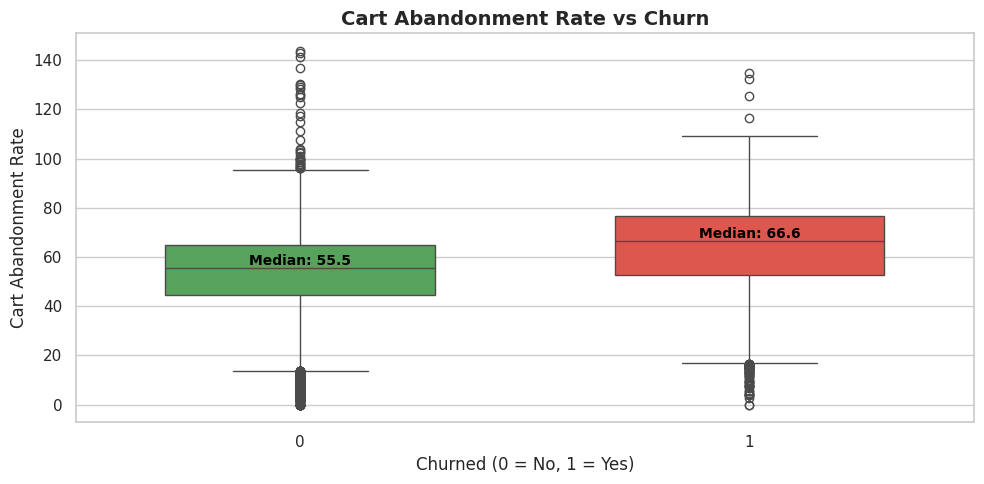

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.boxplot(
    data=df,
    x='Churned',
    y='Cart_Abandonment_Rate',
    palette=['#4CAF50', '#F44336'],
    width=0.6
)

plt.title("Cart Abandonment Rate vs Churn", fontsize=14, fontweight='bold')
plt.xlabel("Churned (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Cart Abandonment Rate", fontsize=12)

# Add median labels
medians = df.groupby("Churned")["Cart_Abandonment_Rate"].median()

for i, median in enumerate(medians):
    ax.text(
        i, median,
        f"Median: {median:.1f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()


## 🛒 Cart Abandonment Rate vs Churn — Boxplot Analysis


### **1️⃣ Churned customers have noticeably higher abandonment rates**
- The median abandonment rate for **non‑churned customers** is around **55.5%**.
- For **churned customers**, the median increases to approximately **66.6%**.
- This upward shift indicates that customers who frequently abandon their carts are **more likely to churn**.

---

### **2️⃣ The distribution is higher for churned users**
- The entire red box (churned group) is positioned higher on the y‑axis.
- This means churned customers consistently show **higher abandonment behavior**, not just a higher median.
- The spread also suggests more variability among churned users.

---


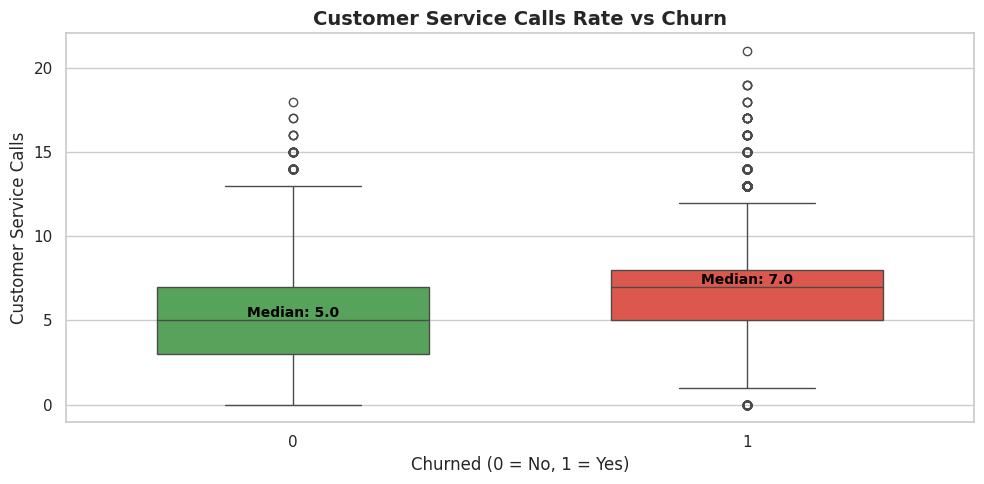

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.boxplot(
    data=df,
    x='Churned',
    y='Customer_Service_Calls',
    palette=['#4CAF50', '#F44336'],
    width=0.6
)

plt.title("Customer Service Calls Rate vs Churn", fontsize=14, fontweight='bold')
plt.xlabel("Churned (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Customer Service Calls", fontsize=12)

# Add median labels
medians = df.groupby("Churned")["Customer_Service_Calls"].median()

for i, median in enumerate(medians):
    ax.text(
        i, median,
        f"Median: {median:.1f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()


## 📞 Customer Service Calls vs Churn — Boxplot Analysis

### **1️⃣ Churned customers make more service calls**
- The median number of calls for **non‑churned customers** is around **5 calls**.
- For **churned customers**, the median increases to roughly **7 calls**.
- This upward shift suggests that customers who frequently contact support are **more likely to churn**.

---

### **2️⃣ Higher distribution for churned users**
- The red box (churned group) is positioned higher on the y‑axis.
- This indicates that churned customers consistently make **more service calls**, not just a higher median.
- The spread also shows greater variability among churned users.





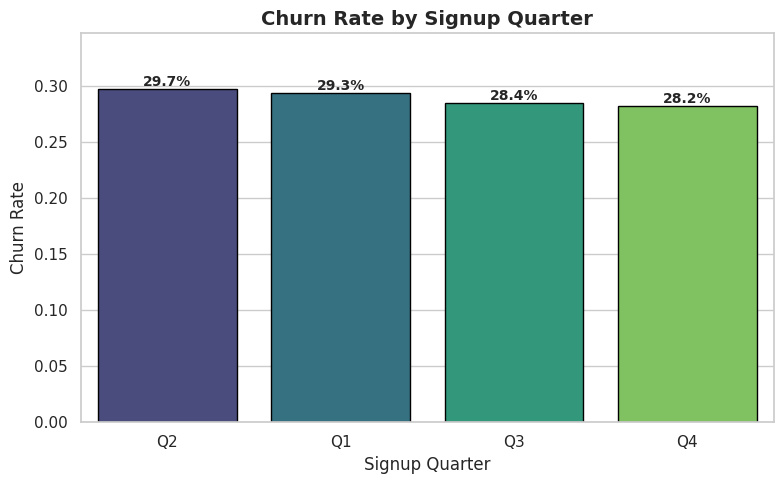

In [ ]:
signup_churn = (
    df.groupby('Signup_Quarter')['Churned']
    .mean()
    .reset_index()
    .sort_values('Churned', ascending=False)
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=signup_churn,
    x='Signup_Quarter',
    y='Churned',
    palette='viridis',
    edgecolor='black'
)

plt.title("Churn Rate by Signup Quarter", fontsize=14, fontweight='bold')
plt.ylabel("Churn Rate", fontsize=12)
plt.xlabel("Signup Quarter", fontsize=12)
plt.ylim(0, signup_churn['Churned'].max() + 0.05)

# Add percentage labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height*100:.1f}%",
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


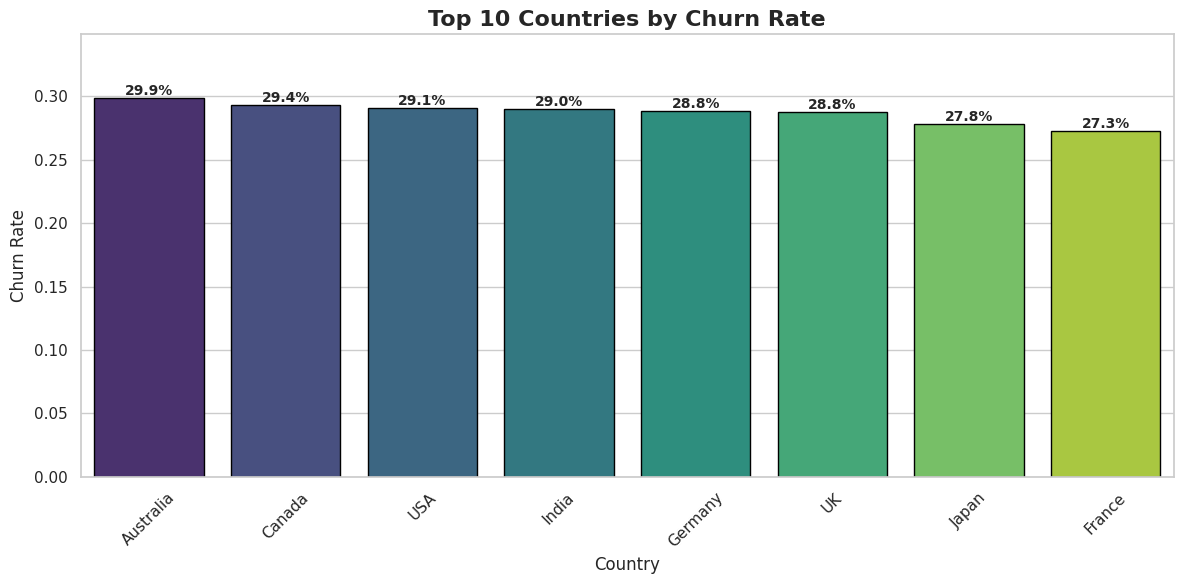

In [ ]:
country_churn = (
    df.groupby('Country')['Churned']
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

top_countries = country_churn.head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=top_countries,
    x='Country',
    y='Churned',
    palette='viridis',
    edgecolor='black'
)

plt.title("Top 10 Countries by Churn Rate", fontsize=16, fontweight='bold')
plt.ylabel("Churn Rate", fontsize=12)
plt.xlabel("Country", fontsize=12)
plt.xticks(rotation=45, fontsize=11)
plt.yticks(fontsize=11)
plt.ylim(0, top_countries['Churned'].max() + 0.05)

# Add churn % labels on bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height*100:.1f}%",
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.preprocessing import StandardScaler

engagement_features = [
    'Login_Frequency',
    'Session_Duration_Avg',
    'Pages_Per_Session',
    'Mobile_App_Usage'
]

scaler = StandardScaler()
scaled_engagement = scaler.fit_transform(df[engagement_features])

df['Engagement_Score'] = scaled_engagement.mean(axis=1)


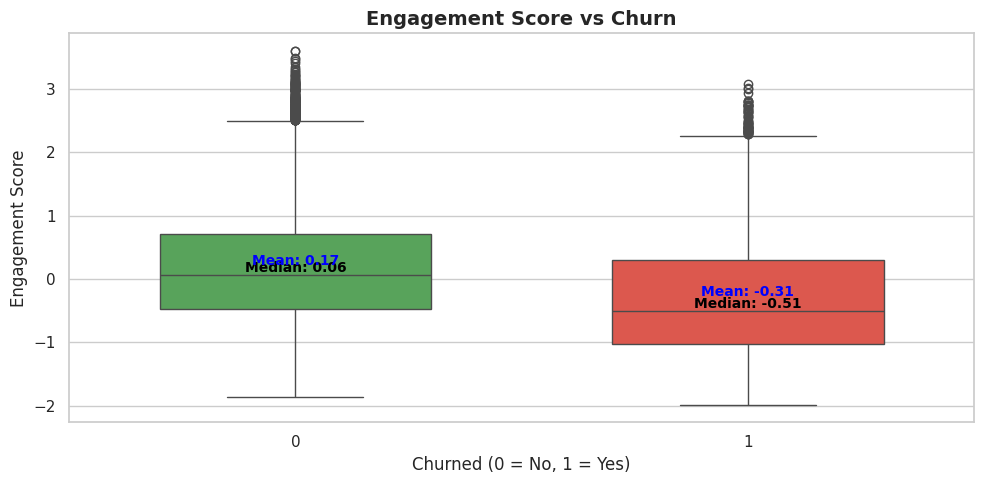

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.boxplot(
    data=df,
    x='Churned',
    y='Engagement_Score',
    palette=['#4CAF50', '#F44336'],   # Green = retained, Red = churned
    width=0.6
)

plt.title("Engagement Score vs Churn", fontsize=14, fontweight='bold')
plt.xlabel("Churned (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Engagement Score", fontsize=12)

# Add median labels
medians = df.groupby("Churned")["Engagement_Score"].median()

for i, median in enumerate(medians):
    ax.text(
        i, median,
        f"Median: {median:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

# Add mean labels (optional but insightful)
means = df.groupby("Churned")["Engagement_Score"].mean()

for i, mean in enumerate(means):
    ax.text(
        i, mean,
        f"Mean: {mean:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='blue'
    )

plt.tight_layout()
plt.show()


In [ ]:
df['Inactivity_Score'] = (
    df['Days_Since_Last_Purchase']
    - df['Engagement_Score']
)


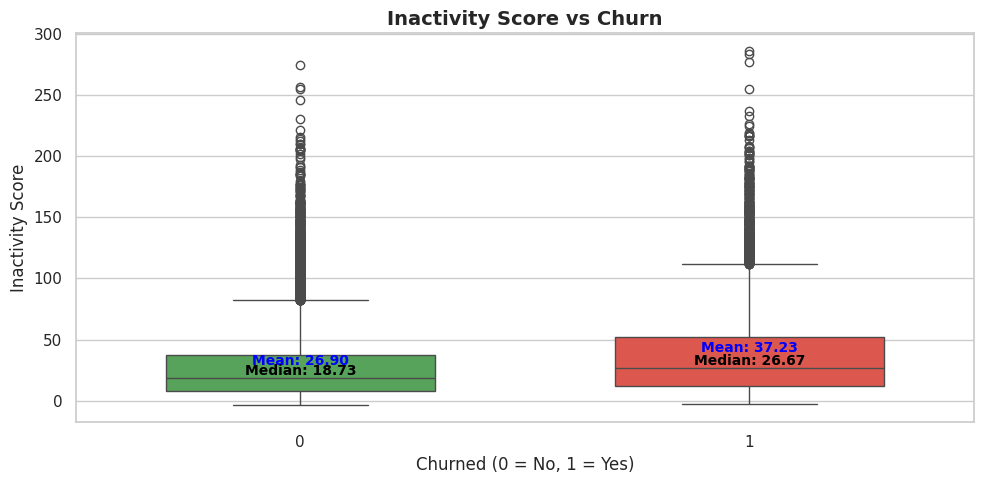

In [ ]:
plt.figure(figsize=(10,5))

ax = sns.boxplot(
    data=df,
    x='Churned',
    y='Inactivity_Score',
    palette=['#4CAF50', '#F44336'],   # Green = retained, Red = churned
    width=0.6
)

plt.title("Inactivity Score vs Churn", fontsize=14, fontweight='bold')
plt.xlabel("Churned (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Inactivity Score", fontsize=12)

# Add median labels
medians = df.groupby("Churned")["Inactivity_Score"].median()

for i, median in enumerate(medians):
    ax.text(
        i, median,
        f"Median: {median:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

# Add mean labels
means = df.groupby("Churned")["Inactivity_Score"].mean()

for i, mean in enumerate(means):
    ax.text(
        i, mean,
        f"Mean: {mean:.2f}",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='blue'
    )

plt.tight_layout()
plt.show()


# Data Cleaning

In [ ]:
df = df[(df['Age'] >= 18)&(df['Age'] < 100) | (df['Age'].isnull())]
df = df[df['Total_Purchases'] >= 0]
df = df[df['Cart_Abandonment_Rate'] <= 100]

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49880 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47390 non-null  float64
 1   Gender                         49880 non-null  object 
 2   Country                        49880 non-null  object 
 3   City                           49880 non-null  object 
 4   Membership_Years               49880 non-null  float64
 5   Login_Frequency                49880 non-null  float64
 6   Session_Duration_Avg           46490 non-null  float64
 7   Pages_Per_Session              46886 non-null  float64
 8   Cart_Abandonment_Rate          49880 non-null  float64
 9   Wishlist_Items                 45892 non-null  float64
 10  Total_Purchases                49880 non-null  float64
 11  Average_Order_Value            49880 non-null  float64
 12  Days_Since_Last_Purchase       46885 non-null  floa

In [ ]:
missing_df = (
    df.isnull()
      .sum()
      .to_frame(name='Missing_Count')
)

missing_df['Missing_Percentage'] = (missing_df['Missing_Count'] / len(df)) * 100

missing_df = missing_df.sort_values('Missing_Percentage', ascending=False)

missing_df


,Missing_Count,Missing_Percentage
Inactivity_Score,12964,25.990377
Engagement_Score,10583,21.216921
Social_Media_Engagement_Score,5984,11.996792
Credit_Balance,5486,10.998396
Mobile_App_Usage,4992,10.008019
Returns_Rate,4474,8.969527
Wishlist_Items,3988,7.995188
Product_Reviews_Written,3496,7.008821
Discount_Usage_Rate,3492,7.000802
Session_Duration_Avg,3390,6.796311


In [ ]:
# Select only the numerical columns without target
target = 'Churned'

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target if present
if target in numerical_columns:
    numerical_columns.remove(target)
for col in numerical_columns:
  median_value=df[col].median()
  df[col].fillna(median_value,inplace=True)

categorical_columns = [
    col for col in df.columns
    if col not in numerical_columns+ ['Churned']
]


In [ ]:
df['Engagement_Level'] = pd.qcut(
    df['Engagement_Score'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

In [ ]:
df['Engagement_Level'].value_counts()

,count
Engagement_Level,
Low,16627
High,16627
Medium,16626


In [ ]:
engagement_churn = (
    df.groupby('Engagement_Level')['Churned']
    .mean()
    .reset_index()
)

engagement_churn

,Engagement_Level,Churned
0,Low,0.391351
1,Medium,0.276976
2,High,0.198593


In [ ]:
engagement_churn = (
    df.groupby('Engagement_Level')['Churned']
    .mean()
    .reset_index()
)
engagement_churn

,Engagement_Level,Churned
0,Low,0.391351
1,Medium,0.276976
2,High,0.198593


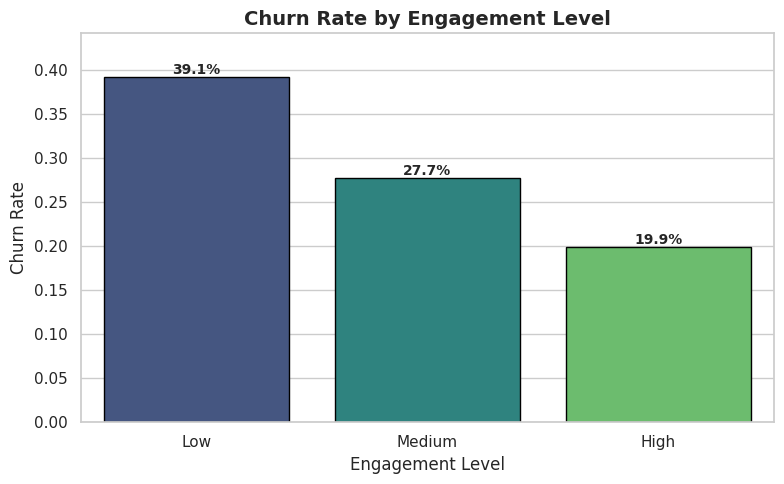

In [ ]:
engagement_churn = (
    df.groupby('Engagement_Level')['Churned']
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=engagement_churn,
    x='Engagement_Level',
    y='Churned',
    palette='viridis',
    edgecolor='black'
)

plt.title("Churn Rate by Engagement Level", fontsize=14, fontweight='bold')
plt.ylabel("Churn Rate", fontsize=12)
plt.xlabel("Engagement Level", fontsize=12)
plt.ylim(0, engagement_churn['Churned'].max() + 0.05)

# Add percentage labels
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height*100:.1f}%",
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


In [ ]:
df.isnull().sum()

,0
Age,0
Gender,0
Country,0
City,0
Membership_Years,0
Login_Frequency,0
Session_Duration_Avg,0
Pages_Per_Session,0
Cart_Abandonment_Rate,0
Wishlist_Items,0


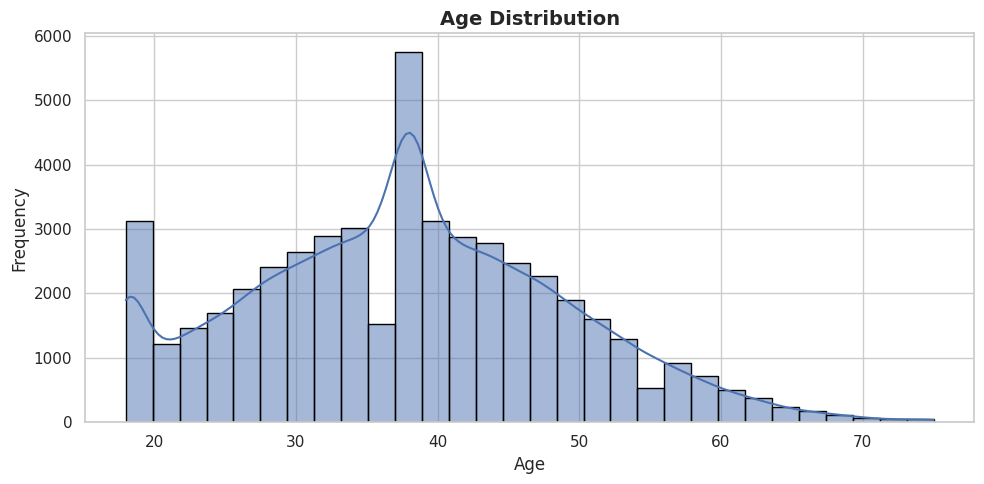

In [ ]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df,
    x='Age',
    bins=30,
    kde=True,
    color='#4C72B0',
    edgecolor='black'
)

plt.title("Age Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.tight_layout()
plt.show()


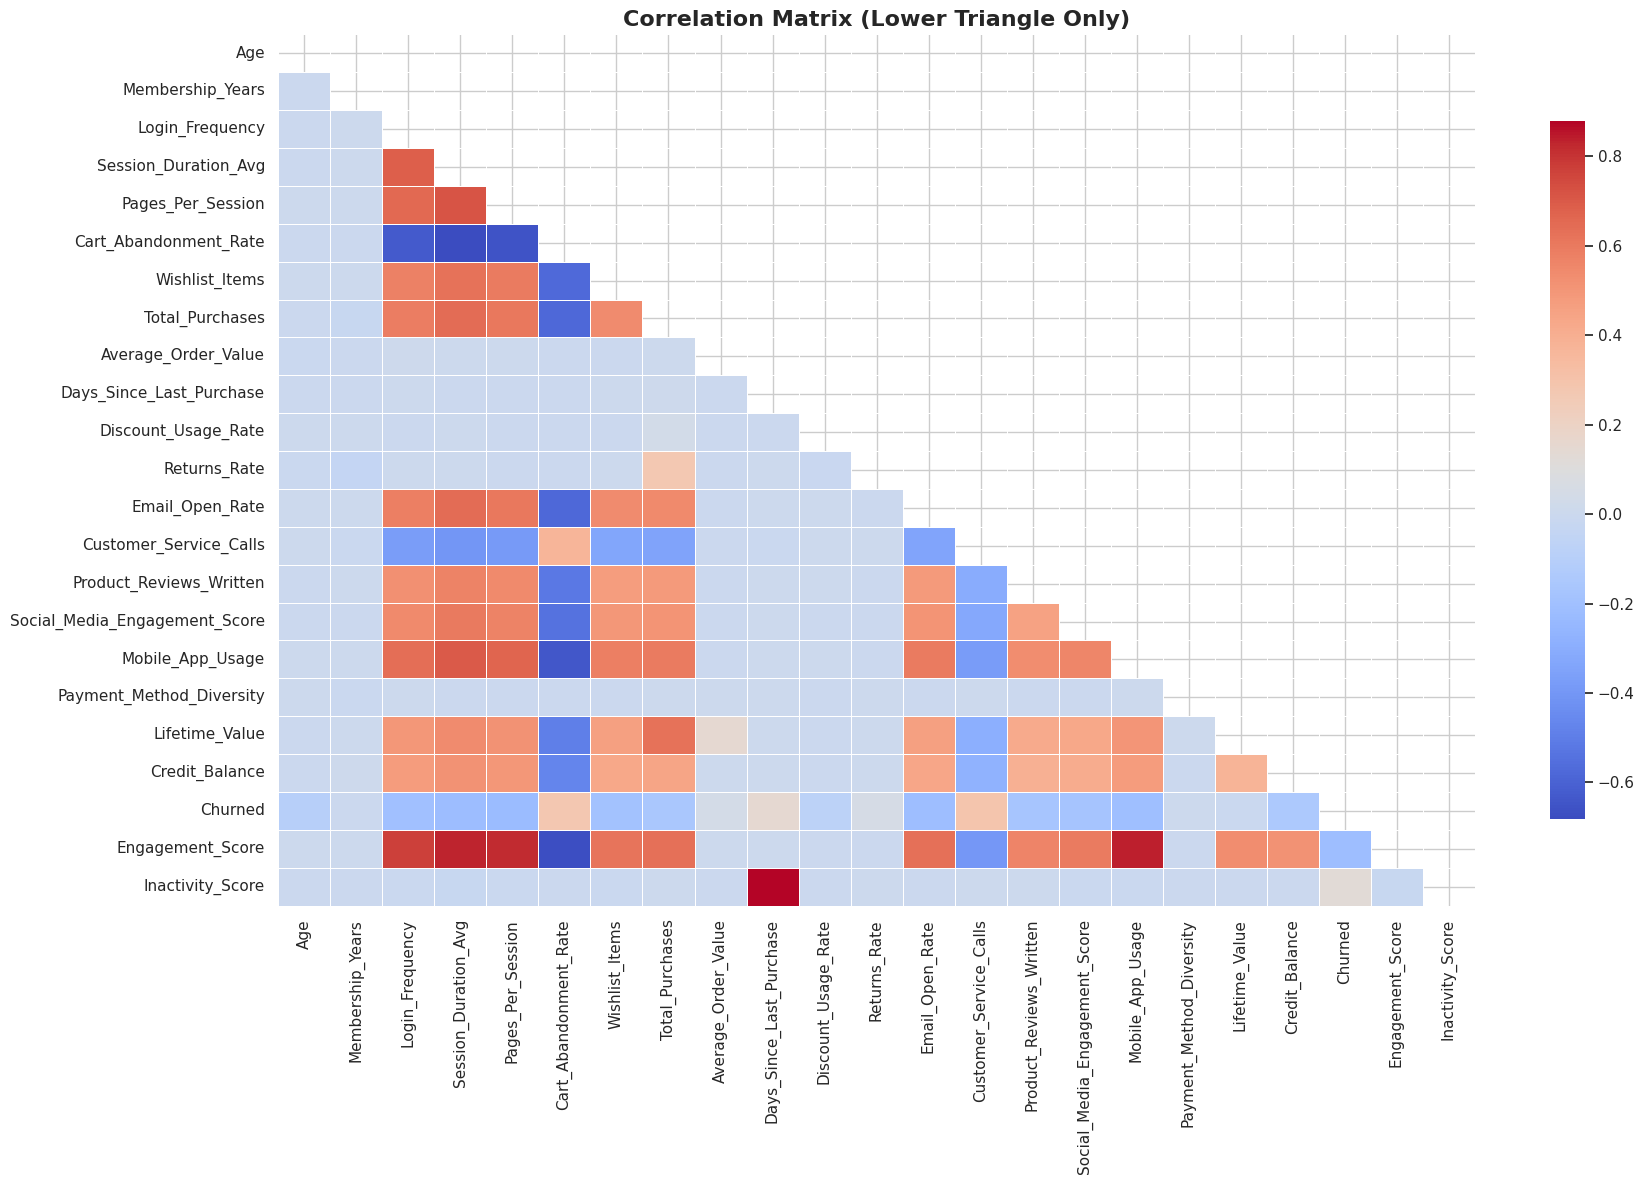

In [ ]:
plt.figure(figsize=(18,12))

corr = df.corr(numeric_only=True)

# Mask upper triangle for readability
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(
    corr,
    mask=mask,
    annot=False,
    cmap='coolwarm',
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix (Lower Triangle Only)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


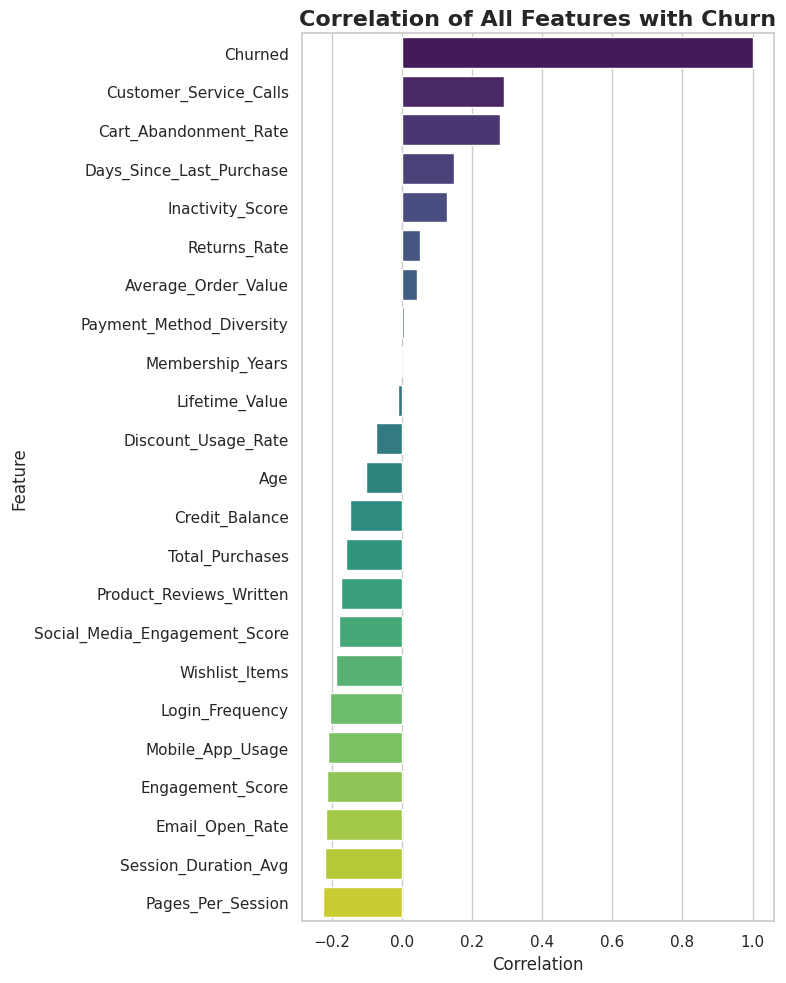

In [ ]:
target_corr = (
    corr['Churned']
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,10))

sns.barplot(
    x=target_corr.values,
    y=target_corr.index,
    palette='viridis'
)

plt.title("Correlation of All Features with Churn", fontsize=16, fontweight='bold')
plt.xlabel("Correlation")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("corr.jpeg")
plt.show()


# Reusable codes and Functions


In [ ]:
# Select only the numerical columns without target
target = 'Churned'

numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target if present
if target in numerical_columns:
    numerical_columns.remove(target)


In [ ]:
def classification_report_print(y_true, y_pred, model_name="Model"):
    """
    Prints key classification metrics in a clean format.

    Parameters:
    - y_true: Actual labels
    - y_pred: Predicted labels
    - model_name: Name of the model (optional)
    """

    print(f"=== {model_name} Performance Metrics ===")
    print(f"Accuracy      : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision     : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall        : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score      : {f1_score(y_true, y_pred):.4f}")


In [ ]:
def confusion_matrix_print(y_true, y_pred, model_name="Model"):
    """
    Plots a clean confusion matrix heatmap.

    Parameters:
    - y_true: Actual labels
    - y_pred: Predicted labels
    - model_name: Name of the model (optional)
    """

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", linewidths=0.5)
    plt.title(f"Confusion Matrix — {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


In [ ]:
def plot_roc_curve(y_true, y_proba, model_name="Model"):
    """
    Plots the ROC curve and prints the AUC score.

    Parameters:
    - y_true: Actual labels (0/1)
    - y_proba: Predicted probabilities for the positive class
    - model_name: Name of the model (string)
    """

    auc = roc_auc_score(y_true, y_proba)
    fpr, tpr, _ = roc_curve(y_true, y_proba)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"{model_name} AUC = {auc:.3f}", linewidth=2)
    plt.plot([0,1], [0,1], 'k--', linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve — {model_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

In [ ]:
def plot_precision_recall_curve(y_true, y_proba, model_name="Model"):
    """
    Plots the Precision–Recall curve and prints the Average Precision (AP) score.

    Parameters:
    - y_true: Actual labels (0/1)
    - y_proba: Predicted probabilities for the positive class
    - model_name: Name of the model (string)
    """

    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)

    plt.figure(figsize=(6,4))
    plt.plot(recall, precision, label=f"{model_name} AP = {ap:.3f}", linewidth=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision–Recall Curve — {model_name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# Feature Preprocessing & Model Pipeline Setup

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_columns)
    ]
)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49880 entries, 0 to 49999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Age                            49880 non-null  float64 
 1   Gender                         49880 non-null  object  
 2   Country                        49880 non-null  object  
 3   City                           49880 non-null  object  
 4   Membership_Years               49880 non-null  float64 
 5   Login_Frequency                49880 non-null  float64 
 6   Session_Duration_Avg           49880 non-null  float64 
 7   Pages_Per_Session              49880 non-null  float64 
 8   Cart_Abandonment_Rate          49880 non-null  float64 
 9   Wishlist_Items                 49880 non-null  float64 
 10  Total_Purchases                49880 non-null  float64 
 11  Average_Order_Value            49880 non-null  float64 
 12  Days_Since_Last_Purchase       49880 

In [ ]:
X = df.drop('Churned', axis=1)
y = df['Churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
def run_pipeline(model, preprocessor, X_train, X_test, y_train):
    """
    Fits a pipeline for ANY model and returns predictions + probabilities.
    """

    pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    return pipe, y_pred, y_proba

In [ ]:
# import seaborn as sns
# import matplotlib.pyplot as plt

def plot_top_features(feature_df, top_n=10, title="Top Features"):
    """
    Plots the top N features from a feature importance or coefficient dataframe.

    Parameters:
    - feature_df: DataFrame with columns ['Feature', 'Importance'] or ['Feature', 'Coefficient']
    - top_n: number of top features to plot
    - title: plot title
    """

    # Detect column name (Importance or Coefficient)
    value_col = "Importance" if "Importance" in feature_df.columns else "Coefficient"

    top_features = feature_df.head(top_n)

    plt.figure(figsize=(10, 6))
    sns.barplot(
        x=value_col,
        y="Feature",
        data=top_features,
        palette="Blues_r"
    )
    plt.title(title)
    plt.xlabel(value_col)
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()


In [ ]:
log_pipeline,log_pred,log_proba = run_pipeline(LogisticRegression(max_iter=1000),preprocessor=preprocessor,X_train=X_train,X_test=X_test,y_train=y_train)

In [ ]:
classification_report_print(y_test,log_pred,model_name="Logistic Regression")

=== Logistic Regression Performance Metrics ===
Accuracy      : 0.7735
Precision     : 0.6730
Recall        : 0.4204
F1 Score      : 0.5175


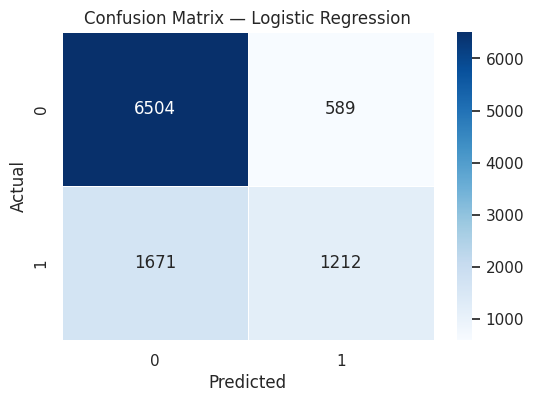

In [ ]:
confusion_matrix_print(y_test,log_pred,model_name="Logistic Regression")

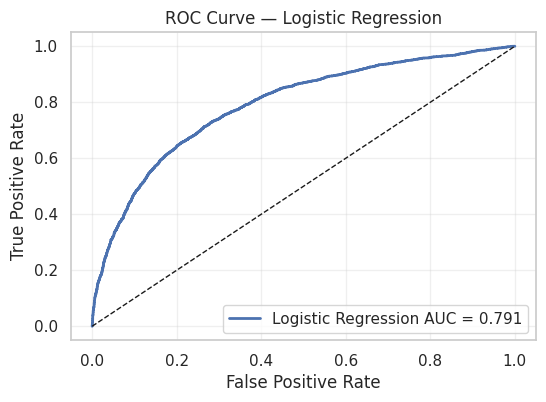

In [ ]:
plot_roc_curve(y_true=y_test,y_proba=log_proba,model_name="Logistic Regression")

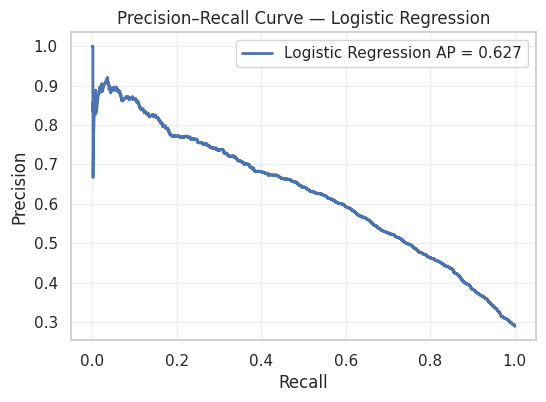

In [ ]:
plot_precision_recall_curve(y_true=y_test,y_proba=log_proba,model_name="Logistic Regression")

In [ ]:
# Extract encoded categorical feature names
cat_features = list(
    log_pipeline.named_steps['preprocess']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_columns)
)
all_features = numerical_columns + cat_features

In [ ]:
coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': log_pipeline.named_steps['model'].coef_[0]
}).sort_values(by='Coefficient', ascending=False)

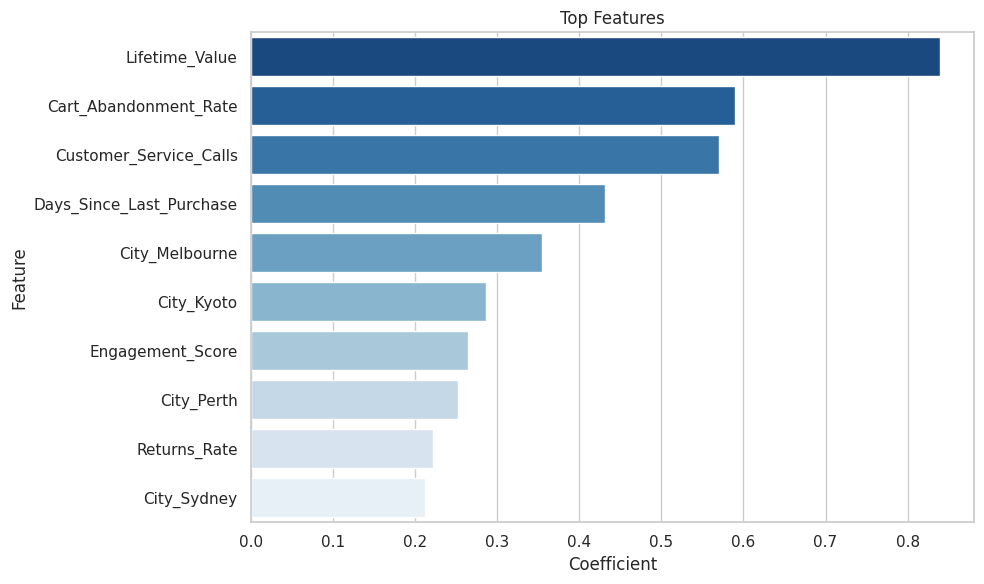

In [ ]:
plot_top_features(coef_df)

In [ ]:
dt_pipeline,dt_pred,dt_proba = run_pipeline(DecisionTreeClassifier(
        max_depth=None,
        min_samples_split=2,
        random_state=42
    ),preprocessor=preprocessor,X_train=X_train,X_test=X_test,y_train=y_train)

In [ ]:
classification_report_print(y_test,dt_pred,model_name="Decision Tree")

=== Decision Tree Performance Metrics ===
Accuracy      : 0.8422
Precision     : 0.7185
Recall        : 0.7464
F1 Score      : 0.7322


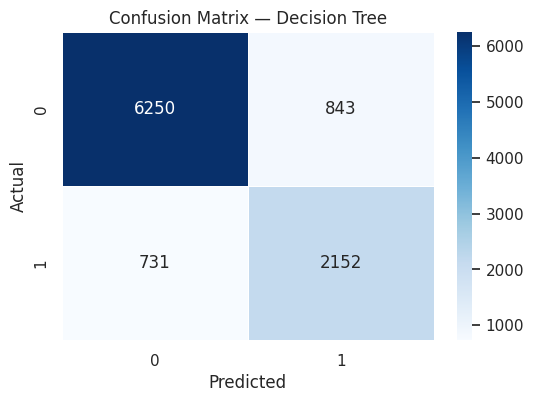

In [ ]:
confusion_matrix_print(y_test,dt_pred,model_name="Decision Tree")

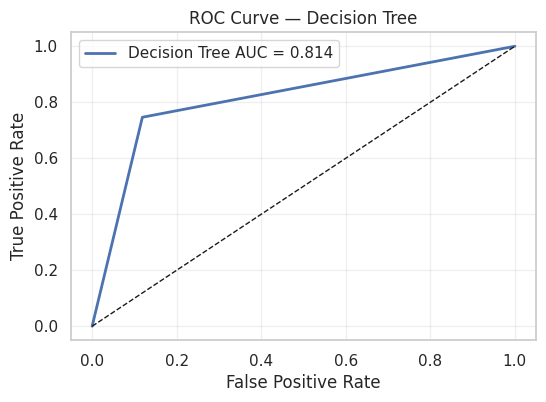

In [ ]:
plot_roc_curve(y_true=y_test,y_proba=dt_proba,model_name="Decision Tree")

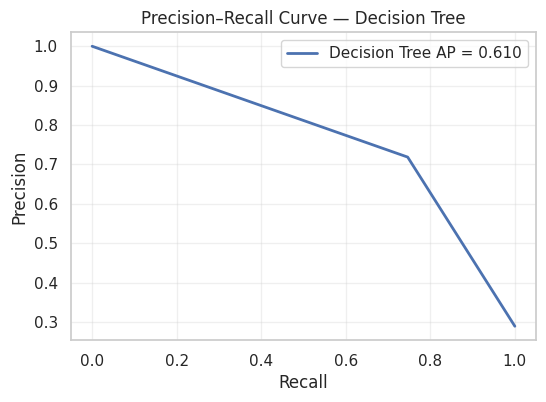

In [ ]:
plot_precision_recall_curve(y_true=y_test,y_proba=dt_proba,model_name="Decision Tree")

In [ ]:
num_features = numerical_columns

cat_features = list(
    dt_pipeline.named_steps['preprocess']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_columns)
)

all_features = num_features + cat_features
importances = dt_pipeline.named_steps['model'].feature_importances_

dt_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


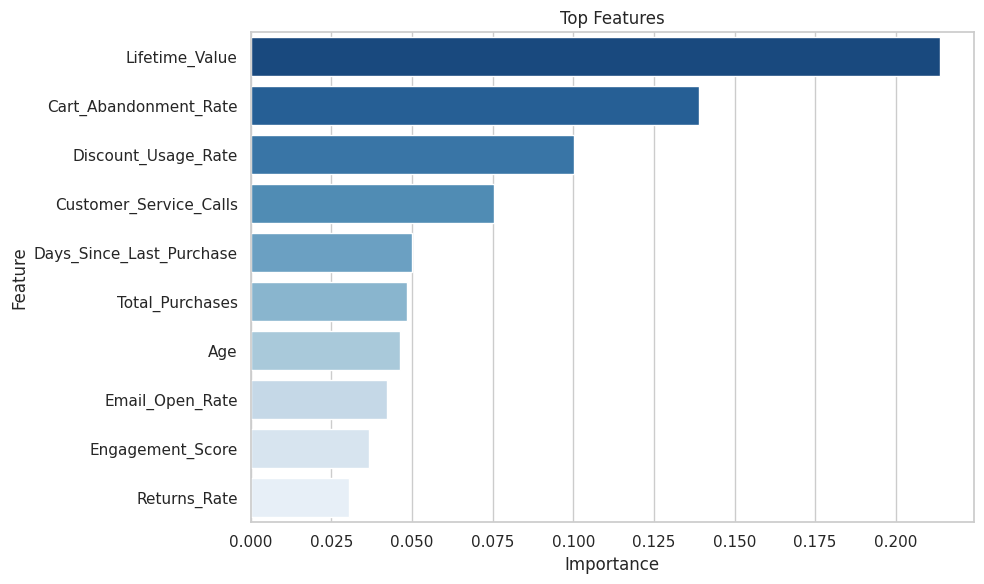

In [ ]:
plot_top_features(dt_importance_df)

In [ ]:
rf_pipeline,rf_pred,rf_proba = run_pipeline(RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    ),preprocessor=preprocessor,X_train=X_train,X_test=X_test,y_train=y_train)

In [ ]:
classification_report_print(y_test,rf_pred,model_name="Random Forest")

=== Random Forest Performance Metrics ===
Accuracy      : 0.9163
Precision     : 0.9173
Recall        : 0.7808
F1 Score      : 0.8435


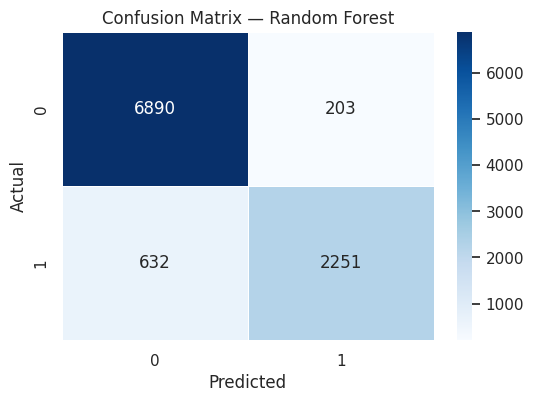

In [ ]:
confusion_matrix_print(y_test,rf_pred,model_name="Random Forest")

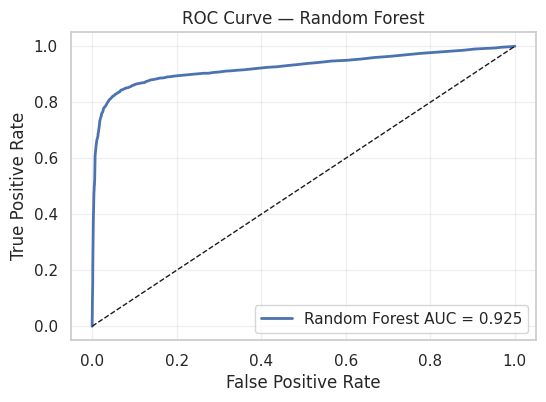

In [ ]:
plot_roc_curve(y_true=y_test,y_proba=rf_proba,model_name="Random Forest")

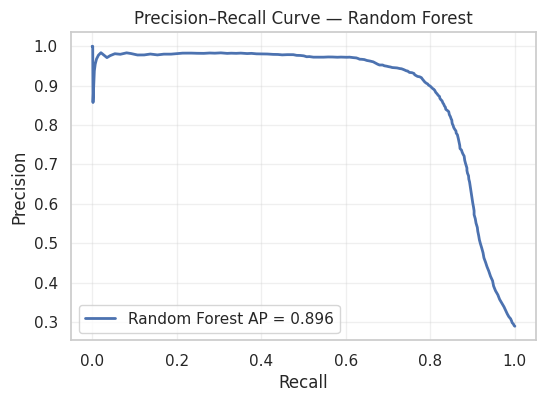

In [ ]:
plot_precision_recall_curve(y_true=y_test,y_proba=rf_proba,model_name="Random Forest")

In [ ]:
num_features = numerical_columns

cat_features = list(
    rf_pipeline.named_steps['preprocess']
    .named_transformers_['cat']
    .get_feature_names_out(cat_cols)
)

all_features = num_features + cat_features
importances = rf_pipeline.named_steps['model'].feature_importances_

rf_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)




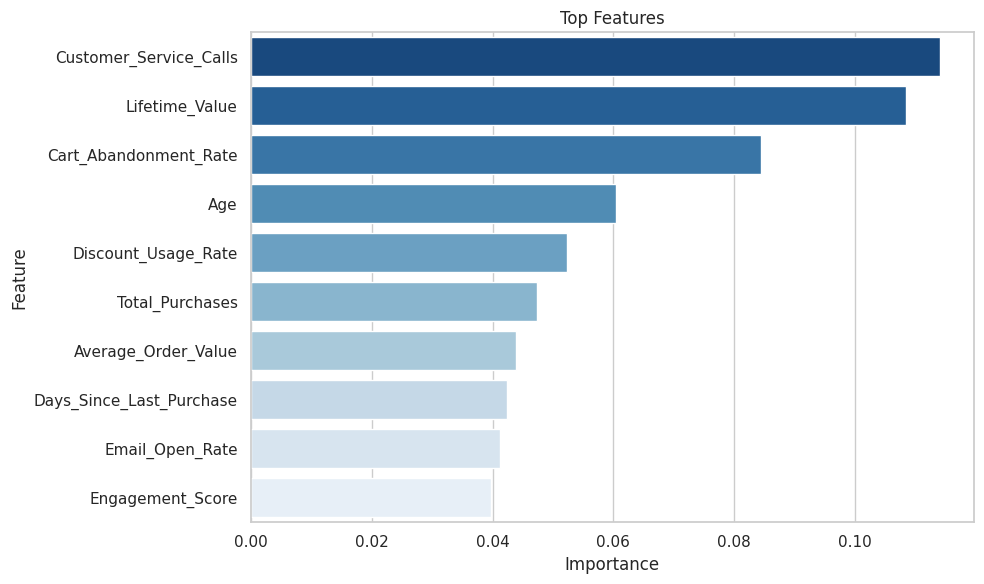

In [ ]:
plot_top_features(rf_importance_df)

In [ ]:
gb_pipeline,gb_pred,gb_proba = run_pipeline(GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ),preprocessor=preprocessor,X_train=X_train,X_test=X_test,y_train=y_train)

In [ ]:
classification_report_print(y_true=y_test,y_pred=gb_pred,model_name="GradientBoost")

=== GradientBoost Performance Metrics ===
Accuracy      : 0.9187
Precision     : 0.9239
Recall        : 0.7832
F1 Score      : 0.8478


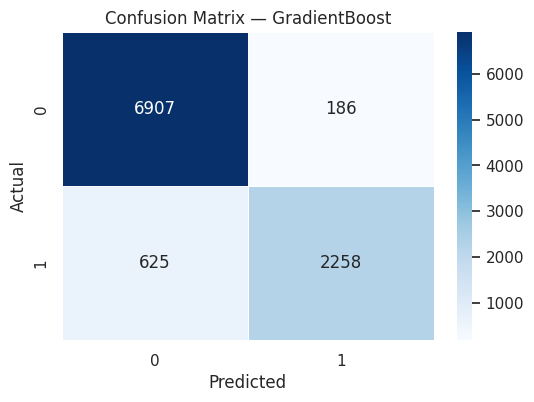

In [ ]:
confusion_matrix_print(y_true=y_test,y_pred=gb_pred,model_name="GradientBoost")

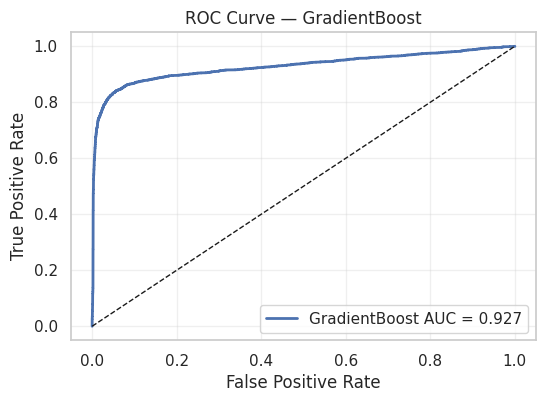

In [ ]:
plot_roc_curve(y_true=y_test,y_proba=gb_proba,model_name="GradientBoost")

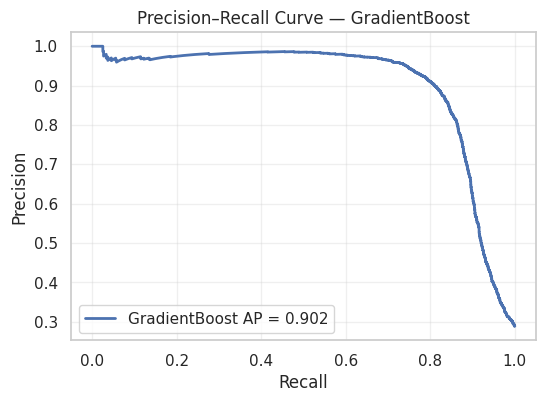

In [ ]:
plot_precision_recall_curve(y_true=y_test,y_proba=gb_proba,model_name="GradientBoost")

In [ ]:
num_features = numerical_columns

cat_features = list(
    gb_pipeline.named_steps['preprocess']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_columns)
)

all_features = num_features + cat_features
importances = gb_pipeline.named_steps['model'].feature_importances_

gb_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

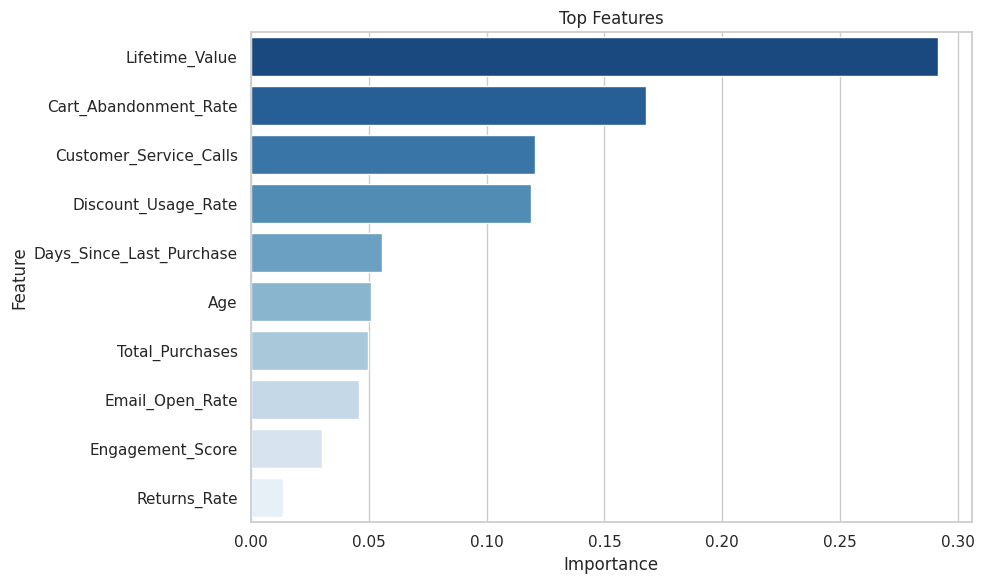

In [ ]:
plot_top_features(gb_importance_df)

In [ ]:
xgb_pipeline,xgb_pred,xgb_proba = run_pipeline(XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    ),preprocessor=preprocessor,X_train=X_train,X_test=X_test,y_train=y_train)

In [ ]:
classification_report_print(y_true=y_test,y_pred=xgb_pred,model_name="X GradientBoost")

=== X GradientBoost Performance Metrics ===
Accuracy      : 0.9205
Precision     : 0.9197
Recall        : 0.7943
F1 Score      : 0.8524


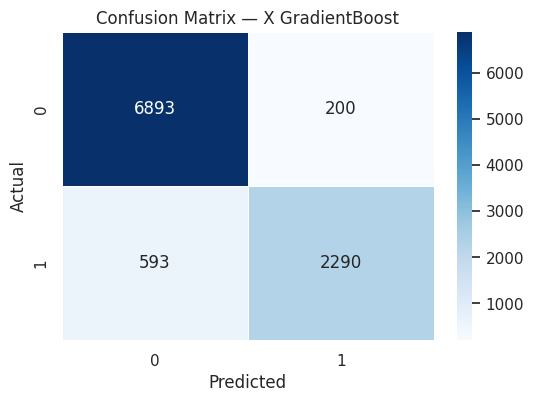

In [ ]:
confusion_matrix_print(y_true=y_test,y_pred=xgb_pred,model_name="X GradientBoost")

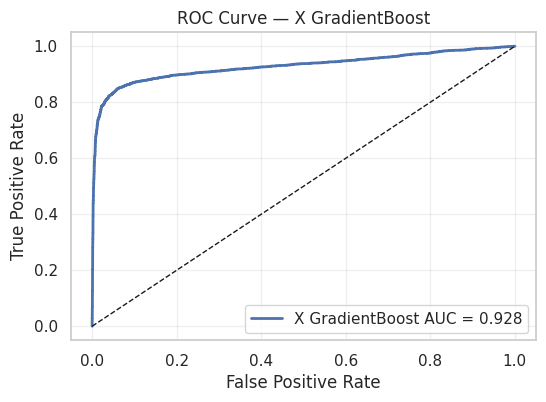

In [ ]:
plot_roc_curve(y_true=y_test,y_proba=xgb_proba,model_name="X GradientBoost")

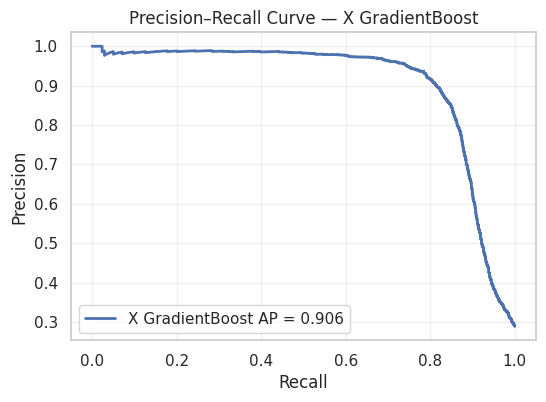

In [ ]:
plot_precision_recall_curve(y_true=y_test,y_proba=xgb_proba,model_name="X GradientBoost")

In [ ]:
num_features = numerical_columns

cat_features = list(
    xgb_pipeline.named_steps['preprocess']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_columns)
)

all_features = num_features + cat_features
importances = xgb_pipeline.named_steps['model'].feature_importances_

xgb_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

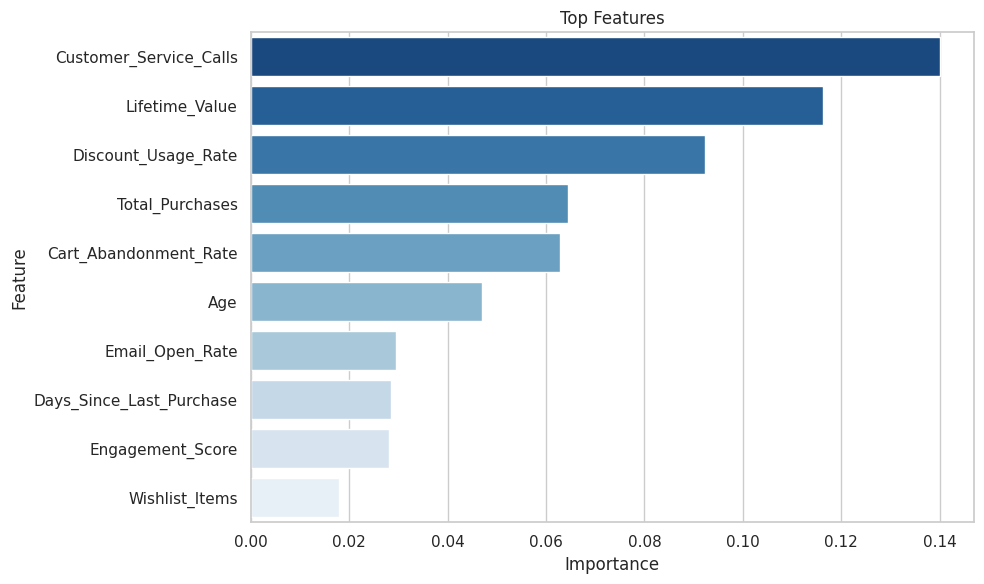

In [ ]:
plot_top_features(xgb_importance_df)

In [ ]:
lgbm_pipeline,lgbm_pred,lgbm_proba = run_pipeline(LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),preprocessor=preprocessor,X_train=X_train,X_test=X_test,y_train=y_train)

[LightGBM] [Info] Number of positive: 11531, number of negative: 28373
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013880 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3972
[LightGBM] [Info] Number of data points in the train set: 39904, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.288969 -> initscore=-0.900399
[LightGBM] [Info] Start training from score -0.900399


In [ ]:
classification_report_print(y_true=y_test,y_pred=lgbm_pred,model_name="LGBM")

=== LGBM Performance Metrics ===
Accuracy      : 0.9208
Precision     : 0.9164
Recall        : 0.7988
F1 Score      : 0.8536


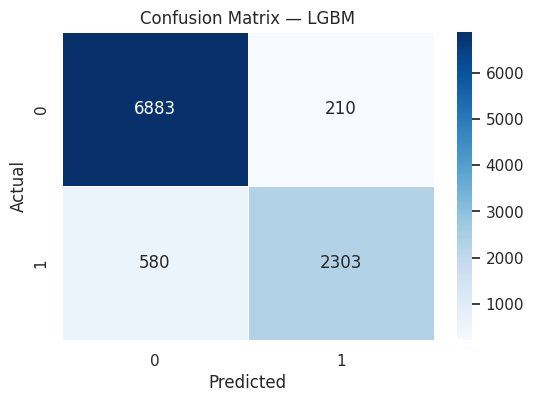

In [ ]:
confusion_matrix_print(y_true=y_test,y_pred=lgbm_pred,model_name="LGBM")

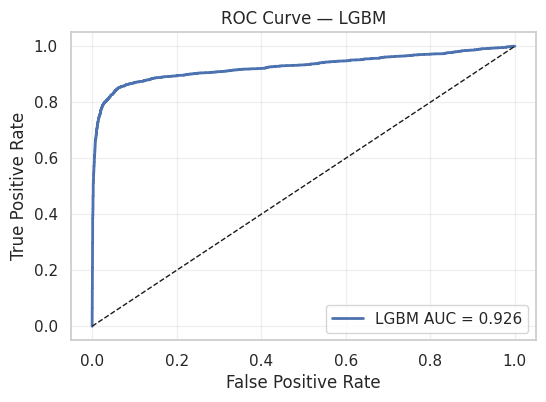

In [ ]:
plot_roc_curve(y_true=y_test,y_proba=lgbm_proba,model_name="LGBM")

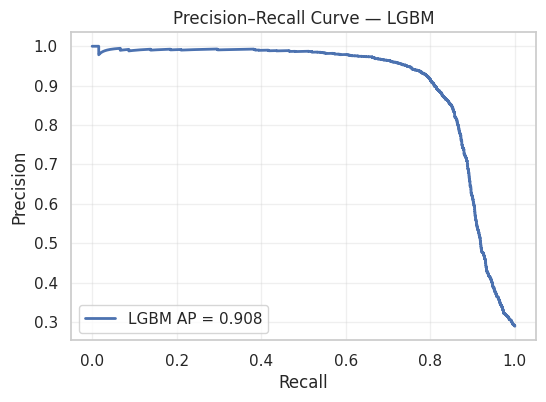

In [ ]:
plot_precision_recall_curve(y_true=y_test,y_proba=lgbm_proba,model_name="LGBM")

In [ ]:
num_features = numerical_columns

cat_features = list(
    lgbm_pipeline.named_steps['preprocess']
    .named_transformers_['cat']
    .get_feature_names_out(categorical_columns)
)

all_features = num_features + cat_features
importances = lgbm_pipeline.named_steps['model'].feature_importances_

lgbm_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

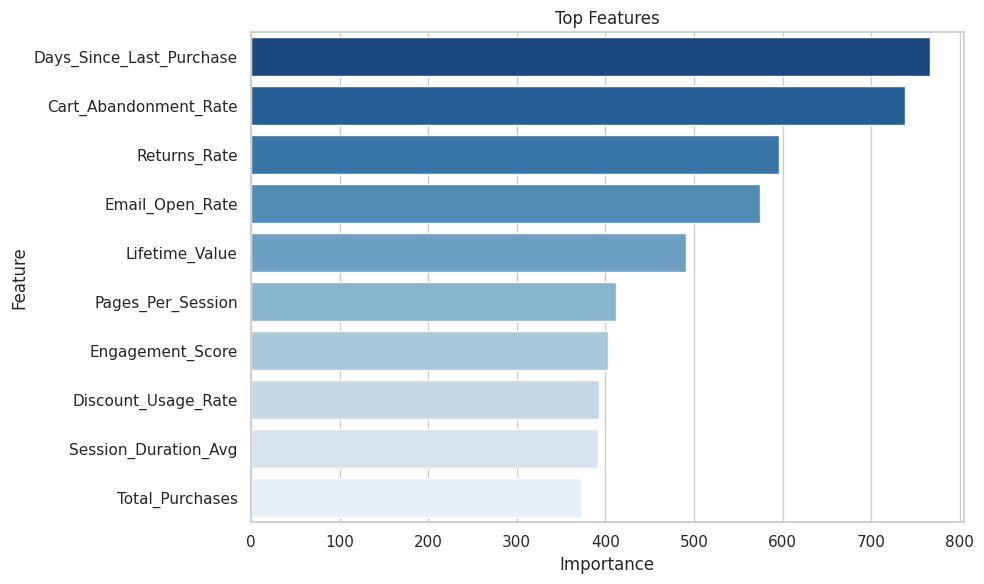

In [ ]:
plot_top_features(lgbm_importance_df)

In [ ]:
def evaluate_model(name, y_true, y_pred, y_proba):
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'ROC-AUC': roc_auc_score(y_true, y_proba)
    }

In [ ]:
results = []

results.append(evaluate_model("Logistic Regression", y_test, log_pred, log_proba))
results.append(evaluate_model("Decision Tree", y_test, dt_pred, dt_proba))
results.append(evaluate_model("Random Forest", y_test, rf_pred, rf_proba))
results.append(evaluate_model("Gradient Boosting", y_test, gb_pred, gb_proba))
results.append(evaluate_model("XGBoost", y_test, xgb_pred, xgb_proba))
results.append(evaluate_model("LightGBM", y_test, lgbm_pred, lgbm_proba))

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='ROC-AUC', ascending=False)
results_df


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
4,XGBoost,0.920509,0.919679,0.794311,0.852410,0.928009
3,Gradient Boosting,0.918705,0.923895,0.783212,0.847757,0.927376
5,LightGBM,0.920810,0.916435,0.798821,0.853595,0.926449
2,Random Forest,0.916299,0.917278,0.780784,0.843545,0.924957
1,Decision Tree,0.842221,0.718531,0.746445,0.732222,0.813798
0,Logistic Regression,0.773456,0.672959,0.420395,0.517506,0.790548


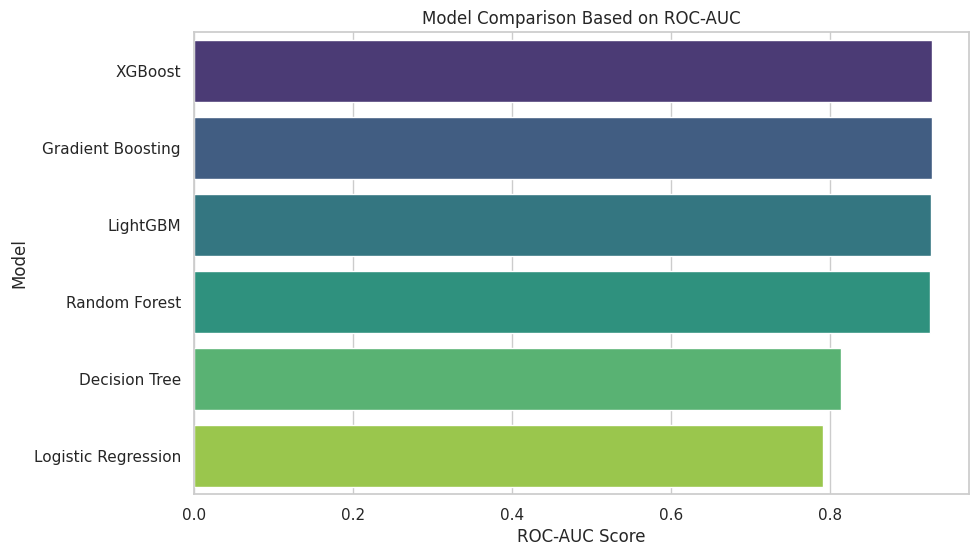

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(data=results_df, x='ROC-AUC', y='Model', palette='viridis')
plt.title("Model Comparison Based on ROC-AUC")
plt.xlabel("ROC-AUC Score")
plt.ylabel("Model")
plt.show()


In [ ]:

lgbm_smote_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=-1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])


In [ ]:
lgbm_smote_pipeline.fit(X_train, y_train)
lgb_pred = lgbm_smote_pipeline.predict(X_test)
lgb_proba = lgbm_smote_pipeline.predict_proba(X_test)[:, 1]

results.append(evaluate_model("LightGBM + SMOTE", y_test, lgb_pred, lgb_proba))


[LightGBM] [Info] Number of positive: 28373, number of negative: 28373
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.057539 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17872
[LightGBM] [Info] Number of data points in the train set: 56746, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [ ]:
xgb_smote_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ))
])
xgb_smote_pipeline.fit(X_train, y_train)
xgb_pred = xgb_smote_pipeline.predict(X_test)
xgb_proba = xgb_smote_pipeline.predict_proba(X_test)[:, 1]

results.append(evaluate_model("XGB + SMOTE", y_test, xgb_pred, xgb_proba))

In [ ]:
gb_smote_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])
gb_smote_pipeline.fit(X_train, y_train)
gb_pred = gb_smote_pipeline.predict(X_test)
gb_proba = gb_smote_pipeline.predict_proba(X_test)[:, 1]

results.append(evaluate_model("GB + SMOTE", y_test, gb_pred, gb_proba))

In [ ]:
rf_smote_pipeline = ImbPipeline(steps=[
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ))
])
rf_smote_pipeline.fit(X_train, y_train)
rf_pred = rf_smote_pipeline.predict(X_test)
rf_proba = rf_smote_pipeline.predict_proba(X_test)[:, 1]

results.append(evaluate_model("RF + SMOTE", y_test, rf_pred, rf_proba))

In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='ROC-AUC', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
6,LightGBM + SMOTE,0.917903,0.901244,0.804024,0.849863,0.928317
4,XGBoost,0.920509,0.919679,0.794311,0.852410,0.928009
8,GB + SMOTE,0.916901,0.901486,0.799861,0.847638,0.927829
3,Gradient Boosting,0.918705,0.923895,0.783212,0.847757,0.927376
7,XGB + SMOTE,0.918805,0.902524,0.806105,0.851594,0.927066
5,LightGBM,0.920810,0.916435,0.798821,0.853595,0.926449
2,Random Forest,0.916299,0.917278,0.780784,0.843545,0.924957
9,RF + SMOTE,0.907578,0.858501,0.814429,0.835885,0.921491
1,Decision Tree,0.842221,0.718531,0.746445,0.732222,0.813798
0,Logistic Regression,0.773456,0.672959,0.420395,0.517506,0.790548


In [ ]:
lgbm_params = {
    'model__n_estimators': [300, 500, 800, 1000],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__num_leaves': [31, 50, 100, 200, 300],
    'model__max_depth': [-1, 5, 10, 20, 30],
    'model__min_child_samples': [10, 20, 30, 50, 100],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__reg_lambda': [0.1, 1, 5, 10],
    'model__reg_alpha': [0, 0.1, 1]
}


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_smote_pipeline,
    param_distributions=lgbm_params,
    n_iter=30,                 # 30 strong trials
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

lgbm_search.fit(X_train, y_train)
best_lgbm_rs = lgbm_search.best_estimator_
best_lgbm_params_rs = lgbm_search.best_params_

best_lgbm_params_rs

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[LightGBM] [Info] Number of positive: 28373, number of negative: 28373
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.029541 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17872
[LightGBM] [Info] Number of data points in the train set: 56746, number of used features: 73
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


{'model__subsample': 0.6,
 'model__reg_lambda': 1,
 'model__reg_alpha': 1,
 'model__num_leaves': 50,
 'model__n_estimators': 500,
 'model__min_child_samples': 50,
 'model__max_depth': 20,
 'model__learning_rate': 0.03,
 'model__colsample_bytree': 1.0}

In [ ]:
lgbm_pred_tuned = best_lgbm_rs.predict(X_test)
lgbm_proba_tuned = best_lgbm_rs.predict_proba(X_test)[:, 1]

results.append(evaluate_model("LightGBM (Tuned)", y_test, lgbm_pred_tuned, lgbm_proba_tuned))

In [ ]:
xgb_params = {
    'model__n_estimators': [300, 500, 800, 1000],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [3, 5, 7, 10],
    'model__min_child_weight': [1, 3, 5, 7],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__colsample_bytree': [0.6, 0.8, 1.0],
    'model__gamma': [0, 1, 5],
    'model__reg_lambda': [0.1, 1, 5, 10],
    'model__reg_alpha': [0, 0.1, 1]
}

In [ ]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_smote_pipeline,
    param_distributions=xgb_params,
    n_iter=30,                 # 30 strong trials
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

xgb_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               ['Age',
                                                                                'Membership_Years',
                                                                                'Login_Frequency',
                                                                                'Session_Duration_Avg',
                                                                                'Pages_Per_Session',
                                                                                'Cart_Abandonment_Rate',
                                                                                'Wishlist_Items',
                                                                                'Total_Purchases',
                                                                                'Average_Order_Value',
                                                                                'Days_Since_Last_Purchase',
                                                                                'Discount_Usage_Rate',
                                                                                'Returns_Rate...
                   param_distributions={'model__colsample_bytree': [0.6, 0.8,
                                                                    1.0],
                                        'model__gamma': [0, 1, 5],
                                        'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [3, 5, 7, 10],
                                        'model__min_child_weight': [1, 3, 5, 7],
                                        'model__n_estimators': [300, 500, 800,
                                                                1000],
                                        'model__reg_alpha': [0, 0.1, 1],
                                        'model__reg_lambda': [0.1, 1, 5, 10],
                                        'model__subsample': [0.6, 0.8, 1.0]},
                   random_state=42, scoring='roc_auc', verbose=2)

In [ ]:
best_xgb = xgb_search.best_estimator_
best_xgb_params = xgb_search.best_params_
xgb_pred_tuned = best_xgb.predict(X_test)
xgb_proba_tuned = best_xgb.predict_proba(X_test)[:, 1]

results.append(evaluate_model("XGBoost (Tuned)", y_test, xgb_pred_tuned, xgb_proba_tuned))

In [ ]:
gb_params = {
    'model__n_estimators': [100, 200, 300, 500, 800],
    'model__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'model__max_depth': [2, 3, 4, 5],
    'model__min_samples_split': [2, 5, 10, 20],
    'model__min_samples_leaf': [1, 2, 4, 8],
    'model__subsample': [0.6, 0.8, 1.0],
    'model__max_features': ['sqrt', 'log2', None],
    'model__loss': ['log_loss']
}


In [ ]:
gb_search = RandomizedSearchCV(
    estimator=gb_smote_pipeline,
    param_distributions=gb_params,
    n_iter=30,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

gb_search.fit(X_train, y_train)

best_gb = gb_search.best_estimator_
best_gb_params = gb_search.best_params_

gb_pred_tuned = best_gb.predict(X_test)
gb_proba_tuned = best_gb.predict_proba(X_test)[:, 1]

results.append(evaluate_model("Gradient Boosting (Tuned)", y_test, gb_pred_tuned, gb_proba_tuned))

Fitting 3 folds for each of 30 candidates, totalling 90 fits


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='ROC-AUC', ascending=False)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
12,Gradient Boosting (Tuned),0.917803,0.903087,0.801596,0.849320,0.929092
6,LightGBM + SMOTE,0.917903,0.901244,0.804024,0.849863,0.928317
11,XGBoost (Tuned),0.918103,0.897002,0.809573,0.851048,0.928154
10,LightGBM (Tuned),0.917903,0.900000,0.805411,0.850082,0.928090
4,XGBoost,0.920509,0.919679,0.794311,0.852410,0.928009
8,GB + SMOTE,0.916901,0.901486,0.799861,0.847638,0.927829
3,Gradient Boosting,0.918705,0.923895,0.783212,0.847757,0.927376
7,XGB + SMOTE,0.918805,0.902524,0.806105,0.851594,0.927066
5,LightGBM,0.920810,0.916435,0.798821,0.853595,0.926449
2,Random Forest,0.916299,0.917278,0.780784,0.843545,0.924957


In [ ]:
def tune_threshold(y_true, y_proba):
    thresholds = np.arange(0.0, 1.01, 0.01)

    results = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        precision = precision_score(y_true, y_pred)
        recall = recall_score(y_true, y_pred)
        f1 = f1_score(y_true, y_pred)

        results.append((t, precision, recall, f1))

    df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])
    return df

In [ ]:
tune_threshold(y_test,lgbm_proba_tuned)

,Threshold,Precision,Recall,F1
0,0.00,0.288994,1.000000,0.448402
1,0.01,0.289023,1.000000,0.448437
2,0.02,0.290759,0.999653,0.450488
3,0.03,0.305538,0.991328,0.467108
4,0.04,0.344658,0.971211,0.508767
...,...,...,...,...
96,0.96,0.987822,0.478321,0.644543
97,0.97,0.989130,0.441901,0.610885
98,0.98,0.990868,0.376344,0.545500
99,0.99,0.995739,0.243149,0.390856


In [ ]:
def auto_select_threshold(y_true, y_proba):
    thresholds = np.arange(0.0, 1.01, 0.01)

    results = []

    for t in thresholds:
        y_pred = (y_proba >= t).astype(int)

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        results.append([t, precision, recall, f1])

    df = pd.DataFrame(results, columns=['Threshold', 'Precision', 'Recall', 'F1'])

    best_recall = df.loc[df['Recall'].idxmax()]
    best_precision = df.loc[df['Precision'].idxmax()]
    best_f1 = df.loc[df['F1'].idxmax()]

    return {
        "best_recall": best_recall,
        "best_precision": best_precision,
        "best_f1": best_f1,
        "full_table": df
    }

In [ ]:
results = auto_select_threshold(y_test,lgbm_proba_tuned)


In [ ]:
results['best_f1']

,49
Threshold,0.490000
Precision,0.896393
Recall,0.810267
F1,0.851157


In [ ]:
results['best_recall']

,0
Threshold,0.000000
Precision,0.288994
Recall,1.000000
F1,0.448402


In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 49880 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                         Non-Null Count  Dtype   
---  ------                         --------------  -----   
 0   Age                            49880 non-null  float64 
 1   Gender                         49880 non-null  object  
 2   Country                        49880 non-null  object  
 3   City                           49880 non-null  object  
 4   Membership_Years               49880 non-null  float64 
 5   Login_Frequency                49880 non-null  float64 
 6   Session_Duration_Avg           49880 non-null  float64 
 7   Pages_Per_Session              49880 non-null  float64 
 8   Cart_Abandonment_Rate          49880 non-null  float64 
 9   Wishlist_Items                 49880 non-null  float64 
 10  Total_Purchases                49880 non-null  float64 
 11  Average_Order_Value            49880 non-null  float64 
 12  Days_Since_Last_Purchase       49880 

In [ ]:
pred_df = X_test.copy()
pred_df['Actual_Churn'] = y_test.values
pred_df['Churn_Probability'] = lgbm_proba_tuned
pred_df['Predicted_Churn'] = (lgbm_proba_tuned >= 0.48).astype(int)

pred_df.to_csv('customer_churn_predictions.csv', index=False)

In [ ]:
churn_cleaned_df=X.copy()


In [ ]:
churn_cleaned_df["Churned"]=y

In [ ]:
churn_cleaned_df.to_csv('Customer_churn_cleaned.csv',index=False)

In [ ]:
results_df.to_csv('model_perfo.csv',index=False)

In [ ]:
preprocess = best_lgbm_rs.named_steps['preprocess']
model = best_lgbm_rs.named_steps['model']
X_test_transformed = preprocess.transform(X_test)
feature_names = preprocess.get_feature_names_out()


In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)


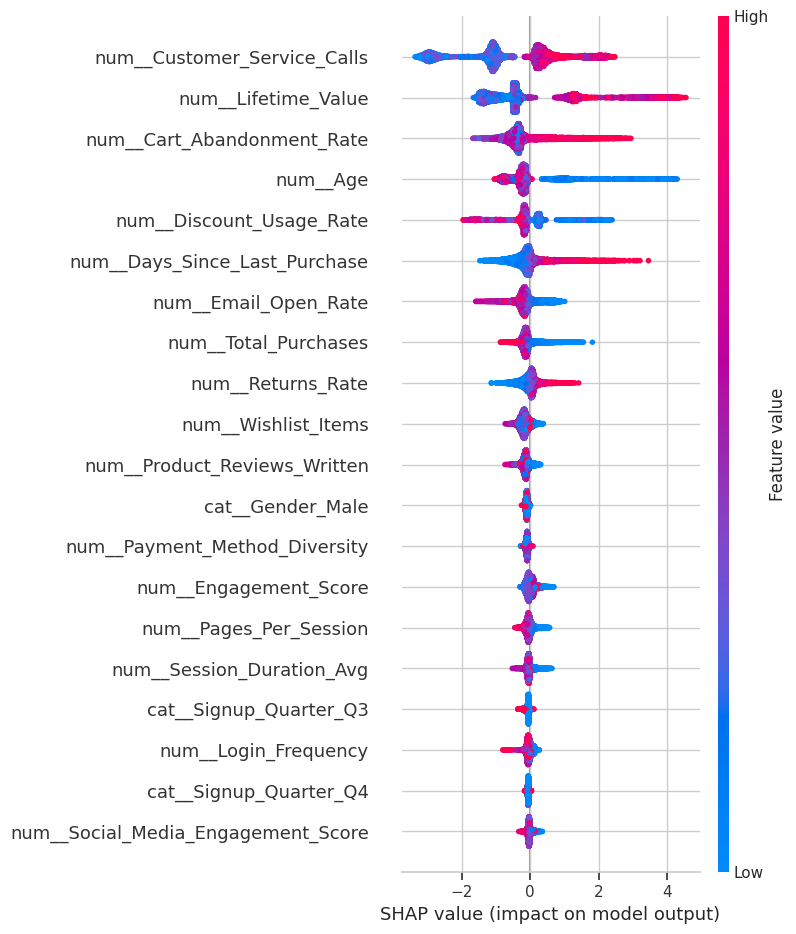

In [ ]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)


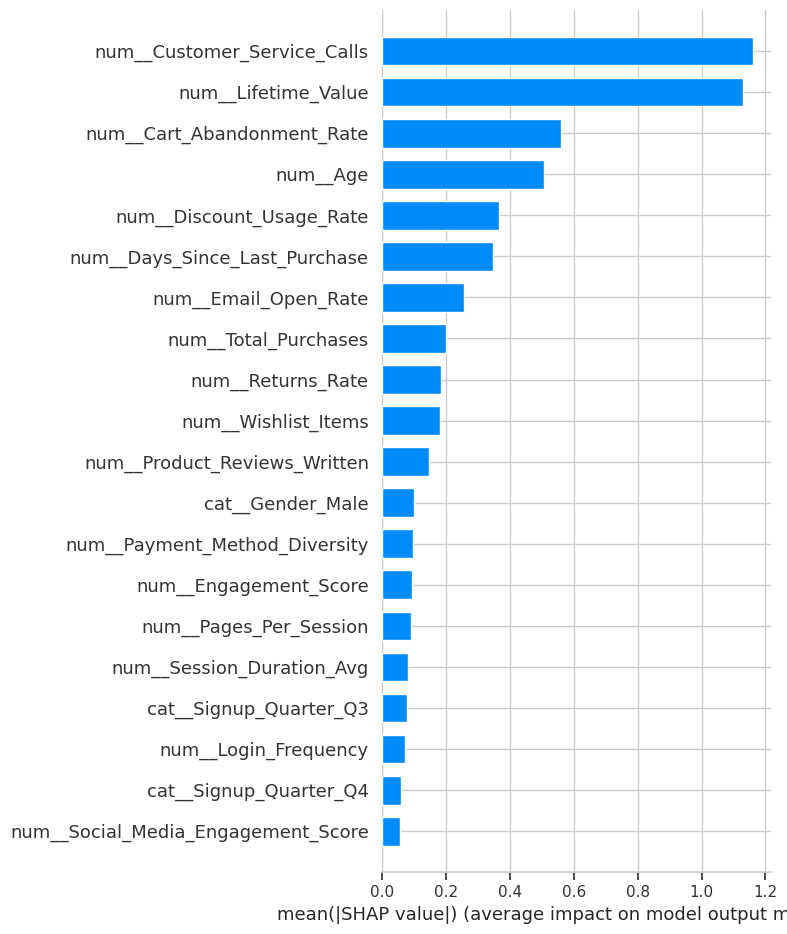

In [ ]:
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names, plot_type="bar")


In [ ]:
customer_index = 10

shap.force_plot(
    explainer.expected_value,
    shap_values[customer_index],
    X_test_transformed[customer_index],
    feature_names=feature_names
)


In [ ]:
from sklearn.pipeline import Pipeline

final_lgbm_pipeline = Pipeline(steps=[
    ('preprocess', preprocess),
    ('model', model)
])


In [ ]:
import joblib

joblib.dump(final_lgbm_pipeline, "churn_model.pkl")


['churn_model.pkl']

In [ ]:
best_threshold = 0.49
joblib.dump(best_threshold, "churn_threshold.pkl")


['churn_threshold.pkl']

In [ ]:
engagement_bins = pd.qcut(
    df['Engagement_Score'],
    q=3,
    retbins=True
)[1]  # this returns the bin edges


In [ ]:
joblib.dump(engagement_bins, "engagement_bins.pkl")


['engagement_bins.pkl']

In [ ]:
X['City'].unique()

array(['Marseille', 'Manchester', 'Vancouver', 'New York', 'Delhi',
       'Tokyo', 'Berlin', 'Houston', 'Calgary', 'Glasgow', 'Munich',
       'Phoenix', 'Paris', 'Ottawa', 'Los Angeles', 'Bangalore',
       'Adelaide', 'Yokohama', 'Sydney', 'Nagoya', 'Frankfurt', 'Cologne',
       'Hamburg', 'Nice', 'Chicago', 'Toulouse', 'Brisbane', 'Leeds',
       'Mumbai', 'Montreal', 'Melbourne', 'Osaka', 'Lyon', 'Hyderabad',
       'Chennai', 'Birmingham', 'London', 'Toronto', 'Perth', 'Kyoto'],
      dtype=object)